# Load Data

In [1]:
import mne
import numpy as np
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
dataset_path = Path('/home/aloo/CNS_Summer_Project_1/Infants_data')

subjects = sorted([d for d in os.listdir(dataset_path) if d.startswith('sub-NORB')])
print(f"Found {len(subjects)} subjects")

Found 103 subjects


In [3]:
def find_edf_files(subject_id):
    """Find all EDF files for a given subject."""
    subject_path = dataset_path / subject_id
    edf_files = []
    
    if subject_path.exists():
        edf_files = list(subject_path.rglob('*.edf'))
    
    return edf_files

test_subject = subjects[68]
edf_files = find_edf_files(test_subject)
print(f"\n{test_subject}:")
print(f"  Found {len(edf_files)} EDF file(s)")
for edf in edf_files:
    print(f"  - {edf.name}")


sub-NORB00069:
  Found 4 EDF file(s)
  - sub-NORB00069_ses-2_task-EEG_eeg.edf
  - sub-NORB00069_ses-1_task-EEG_eeg.edf
  - sub-NORB00069_ses-3_task-EEG_eeg.edf
  - sub-NORB00069_ses-4_task-EEG_eeg.edf


In [4]:
def load_edf_data(edf_path):
    """
    Load EDF file with MNE and extract EEG channels.
    """
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    
    n_channels = len(raw.ch_names)
    sampling_rate = raw.info['sfreq']
    duration = raw.times[-1]
    
    print(f"\nLoaded: {Path(edf_path).name}")
    # print(f"  Channels: {n_channels}")
    # print(f"  Sampling rate: {sampling_rate} Hz")
    # print(f"  Duration: {duration:.2f} seconds")
    # print(f"  Channel names: {raw.ch_names}")
    
    return raw

if edf_files:
    raw = load_edf_data(edf_files[0])
else:
    print("No EDF files found for testing")


Loaded: sub-NORB00069_ses-2_task-EEG_eeg.edf


# Preprocess

In [5]:
def detect_bad_channels(raw, flat_threshold=1e-12, noise_threshold=1e-2):
    """
    Detect bad channels (flat or extremely noisy).
    """
    data = raw.get_data()
    channel_names = raw.ch_names
    bad_channels = []
    
    # Define reference/ground channel names to exclude
    ref_ground_channels = {'PG1', 'PG2', 'REF', 'GND', 'GROUND', '25+', '26+', '27+'}
    
    for i, ch_name in enumerate(channel_names):
        ch_data = data[i, :]
        ch_std = np.std(ch_data)
        ch_range = np.max(ch_data) - np.min(ch_data)
        
        is_bad = False
        
        # Check if flat
        if ch_std < flat_threshold:
            is_bad = True
        
        # Check if too noisy
        elif ch_std > noise_threshold:
            is_bad = True
        
        # Check if constant value
        elif ch_range == 0:
            is_bad = True
        
        # Check for reference/ground channels
        elif ch_name.upper() in ref_ground_channels:
            is_bad = True
        
        if is_bad:
            bad_channels.append(ch_name)
    
    # print(f"\nFound {len(bad_channels)} bad channel(s): {bad_channels}")
    
    return bad_channels

if 'raw' in locals():
    bad_channels = detect_bad_channels(raw)
    
    # Remove bad channels if any found
    if bad_channels:
        raw_clean = raw.copy()
        raw_clean.drop_channels(bad_channels)
        print(f"\nRemoved {len(bad_channels)} bad channel(s)")
        print(f"Remaining channels ({len(raw_clean.ch_names)}): {raw_clean.ch_names}")
    else:
        raw_clean = raw.copy()
        print("\nNo bad channels detected. Proceeding with all channels.")
    
    raw_filtered = raw_clean  # For compatibility with downstream code
else:
    print("Error: 'raw' data not found. Please run Step 1 first.")


No bad channels detected. Proceeding with all channels.


In [6]:
def load_annotations(subject_id, session_id, dataset_path):
    """
    Load annotation file for a given subject and session.
    Handles TSV files with trailing tabs/whitespace robustly.
    """
    annotations_path = dataset_path / 'derivatives' / 'NeuronicEEG' / subject_id / session_id / 'eeg' / f'{subject_id}_{session_id}_task-EEG_annotations.tsv'
    
    if annotations_path.exists():
        # Read file line by line to handle trailing tabs properly
        with open(annotations_path, 'r') as f:
            lines = f.readlines()
        
        # Parse manually to avoid pandas issues with trailing tabs
        data = []
        header = None
        
        for i, line in enumerate(lines):
            # Split by tab and strip whitespace from each field
            fields = [field.strip() for field in line.strip().split('\t')]
            
            if i == 0:
                # Header row
                header = fields[:3]  # Only take first 3 columns: onset, duration, label
            else:
                # Data row - only take first 3 fields
                if len(fields) >= 3 and fields[0] and fields[1]:  # Ensure we have onset and duration
                    try:
                        onset = float(fields[0])
                        duration = float(fields[1])
                        label = fields[2] if fields[2] else 'eyes_closed'  # Default if empty
                        data.append([onset, duration, label])
                    except ValueError:
                        continue  # Skip malformed lines
        
        if data:
            annotations_df = pd.DataFrame(data, columns=['onset', 'duration', 'label'])
            return annotations_df
        else:
            print(f"  Warning: No valid data in annotations file: {annotations_path}")
            return None
    else:
        print(f"  Warning: No annotations file found at {annotations_path}")
        return None

def segment_data_from_annotations(raw, annotations_df, label='eyes_closed'):
    """
    Segment EEG data based on annotations file.
    Only extracts segments marked with the specified label (e.g., 'eyes_closed').
    """
    sfreq = raw.info['sfreq']
    data = raw.get_data()
    n_channels, n_samples = data.shape

    # Normalize labels for robust matching
    label_lower = label.lower().strip()
    ann_labels = annotations_df['label'].fillna('').astype(str).str.lower().str.strip()

    # Second approach: only map Spanish alias when requested label is eyes_closed
    if label_lower == 'eyes_closed':
        filtered_annotations = annotations_df[
            (ann_labels == 'eyes_closed') |
            (ann_labels == 'ojos_cerrados')
        ]
    else:
        filtered_annotations = annotations_df[ann_labels == label_lower]
    
    segments = []
    segment_info = []
    
    # print(f"\nSegmenting data from annotations file...")
    # print(f"  Total annotations: {len(annotations_df)}")
    # print(f"  Unique labels found: {annotations_df['label'].unique().tolist()}")
    # print(f"  Annotations matching '{label}' {len(filtered_annotations)}")
    
    for idx, row in filtered_annotations.iterrows():
        onset = row['onset']  # in seconds
        duration = row['duration']  # in seconds
        
        # Convert to sample indices
        start_sample = int(onset * sfreq)
        end_sample = int((onset + duration) * sfreq)
        
        # Check if segment is within bounds
        if start_sample >= 0 and end_sample <= n_samples:
            segment = data[:, start_sample:end_sample]
            segments.append(segment)
            segment_info.append({
                'onset': onset,
                'duration': duration,
                'start_sample': start_sample,
                'end_sample': end_sample
            })
        else:
            print(f"  Warning: Segment at onset={onset}s exceeds data bounds, skipping")
    
    print(f"\nExtracted {len(segments)} valid segments")
    
    return segments, segment_info

# Apply segmentation based on annotations
if 'raw_clean' in locals():
    # Extract subject and session info from the loaded EDF file
    if 'edf_files' in locals() and edf_files:
        edf_name = edf_files[0].stem
        parts = edf_name.split('_')
        subject_id = parts[0]  # e.g., 'sub-NORB00042'
        session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-1'
        
        # Load annotations
        annotations_df = load_annotations(subject_id, session_id, dataset_path)
        
        if annotations_df is not None:
            # Segment data based on annotations
            segments, segment_info = segment_data_from_annotations(raw_clean, annotations_df, label='eyes_closed')
            
            if len(segments) > 0:
                print(f"\n✓ Successfully segmented data for {subject_id} {session_id}")
            else:
                print(f"\n⚠ No valid segments found for {subject_id} {session_id}")
        else:
            print(f"\n⚠ Could not load annotations. Skipping segmentation.")
    else:
        print("Error: EDF file information not found.")
else:
    print("Error: 'raw_clean' data not found. Please run bad channel detection first.")


Extracted 20 valid segments

✓ Successfully segmented data for sub-NORB00069 ses-2


In [7]:
import networkx as nx


def calculate_betweenness_centrality_from_distance_matrix(distance_matrix, channel_names=None, normalized=True):
    """Calculate betweenness centrality from a distance-style weighted adjacency matrix."""
    distance_matrix = np.asarray(distance_matrix, dtype=float)
    n = distance_matrix.shape[0]

    if channel_names is None:
        channel_names = [f"node_{i}" for i in range(n)]
    elif len(channel_names) != n:
        raise ValueError(f"channel_names must have length {n}. Got {len(channel_names)}.")

    G = nx.Graph()
    G.add_nodes_from(channel_names)

    for i in range(n):
        for j in range(i + 1, n):
            weight = distance_matrix[i, j]
            if np.isfinite(weight):
                G.add_edge(channel_names[i], channel_names[j], weight=float(weight))

    return nx.betweenness_centrality(G, weight='weight', normalized=normalized)


def segment_to_centrality_rows(segment, subject_id, session_id, segment_index, channel_names):
    """Compute correlation, distance, and betweenness centrality for a single EEG segment."""
    corr_matrix = np.corrcoef(segment)
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr_matrix, 1.0)

    abs_corr_matrix = np.abs(corr_matrix)
    distance_matrix = 1.0 - abs_corr_matrix
    np.fill_diagonal(distance_matrix, 0.0)

    centrality = calculate_betweenness_centrality_from_distance_matrix(
        distance_matrix,
        channel_names=channel_names,
        normalized=True,
    )

    rows = []
    for node_name, centrality_value in centrality.items():
        node_index = channel_names.index(node_name)
        rows.append({
            "subject_id": subject_id,
            "session_id": session_id,
            "segment_index": segment_index,
            "node": node_name,
            "node_index": node_index,
            "betweenness_centrality": float(centrality_value),
        })

    return corr_matrix, abs_corr_matrix, distance_matrix, rows


all_segment_node_centrality_rows = []
all_segment_pairwise_rows = []
all_session_summaries = []

for subject_id in subjects:
    subject_edf_files = find_edf_files(subject_id)
    if not subject_edf_files:
        continue

    for edf_path in subject_edf_files:
        raw_subject = load_edf_data(edf_path)
        subject_bad_channels = detect_bad_channels(raw_subject)

        raw_subject_clean = raw_subject.copy()
        if subject_bad_channels:
            raw_subject_clean.drop_channels(subject_bad_channels)

        edf_name = Path(edf_path).stem
        parts = edf_name.split('_')
        session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-1'

        annotations_df_subject = load_annotations(subject_id, session_id, dataset_path)
        if annotations_df_subject is None:
            continue

        segments_subject, segment_info_subject = segment_data_from_annotations(
            raw_subject_clean,
            annotations_df_subject,
            label='eyes_closed',
        )
        if not segments_subject:
            continue

        channel_names_subject = raw_subject_clean.ch_names
        all_session_summaries.append({
            "subject_id": subject_id,
            "session_id": session_id,
            "n_segments": len(segments_subject),
            "n_channels": len(channel_names_subject),
        })

        for segment_index, segment in enumerate(segments_subject, start=1):
            corr_matrix, abs_corr_matrix, distance_matrix, centrality_rows = segment_to_centrality_rows(
                segment,
                subject_id=subject_id,
                session_id=session_id,
                segment_index=segment_index,
                channel_names=channel_names_subject,
            )

            for i, node_i in enumerate(channel_names_subject):
                for j in range(i + 1, len(channel_names_subject)):
                    node_j = channel_names_subject[j]
                    all_segment_pairwise_rows.append({
                        "subject_id": subject_id,
                        "session_id": session_id,
                        "segment_index": segment_index,
                        "node_i": node_i,
                        "node_j": node_j,
                        "pearson_correlation": float(corr_matrix[i, j]),
                        "absolute_correlation": float(abs_corr_matrix[i, j]),
                        "distance": float(distance_matrix[i, j]),
                    })

            all_segment_node_centrality_rows.extend(centrality_rows)

all_segment_pairwise_df = pd.DataFrame(all_segment_pairwise_rows)
all_segment_node_centrality_df = pd.DataFrame(all_segment_node_centrality_rows)
all_session_summaries_df = pd.DataFrame(all_session_summaries)

print(f"Sessions processed: {len(all_session_summaries_df)}")
print(f"Segment-pair rows: {len(all_segment_pairwise_df)}")
print(f"Node-centrality rows: {len(all_segment_node_centrality_df)}")

if not all_segment_node_centrality_df.empty:
    display(all_segment_node_centrality_df.head())
else:
    print("No segment-level centrality values were computed.")


Loaded: sub-NORB00001_ses-1_task-EEG_eeg.edf

Extracted 32 valid segments

Loaded: sub-NORB00002_ses-1_task-EEG_eeg.edf

Extracted 0 valid segments

Loaded: sub-NORB00003_ses-1_task-EEG_eeg.edf

Extracted 36 valid segments

Loaded: sub-NORB00004_ses-1_task-EEG_eeg.edf

Extracted 0 valid segments

Loaded: sub-NORB00005_ses-1_task-EEG_eeg.edf

Extracted 27 valid segments

Loaded: sub-NORB00006_ses-1_task-EEG_eeg.edf

Extracted 23 valid segments

Loaded: sub-NORB00007_ses-1_task-EEG_eeg.edf

Extracted 18 valid segments

Loaded: sub-NORB00008_ses-1_task-EEG_eeg.edf

Extracted 21 valid segments

Loaded: sub-NORB00009_ses-1_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00010_ses-1_task-EEG_eeg.edf

Extracted 26 valid segments

Loaded: sub-NORB00011_ses-1_task-EEG_eeg.edf

Extracted 0 valid segments

Loaded: sub-NORB00012_ses-1_task-EEG_eeg.edf

Extracted 0 valid segments

Loaded: sub-NORB00013_ses-1_task-EEG_eeg.edf

Extracted 17 valid segments

Loaded: sub-NORB00014_ses-1_

,subject_id,session_id,segment_index,node,node_index,betweenness_centrality
0,sub-NORB00001,ses-1,1,Fp1,0,0.104575
1,sub-NORB00001,ses-1,1,Fp2,1,0.078431
2,sub-NORB00001,ses-1,1,F3,2,0.052288
3,sub-NORB00001,ses-1,1,F4,3,0.058824
4,sub-NORB00001,ses-1,1,C3,4,0.000000


In [8]:
if not all_segment_node_centrality_df.empty:
    session_node_centrality_df = (
        all_segment_node_centrality_df
        .groupby(["subject_id", "session_id", "node"], as_index=False)["betweenness_centrality"]
        .mean()
        .rename(columns={"betweenness_centrality": "mean_betweenness_centrality"})
    )

    print(f"Session-level rows: {len(session_node_centrality_df)}")
    display(session_node_centrality_df.head())
else:
    session_node_centrality_df = pd.DataFrame(columns=["subject_id", "session_id", "node", "mean_betweenness_centrality"])
    print("No segment-level centrality data available to aggregate.")

Session-level rows: 2375


,subject_id,session_id,node,mean_betweenness_centrality
0,sub-NORB00001,ses-1,C3,0.045956
1,sub-NORB00001,ses-1,C4,0.028595
2,sub-NORB00001,ses-1,CZ,0.005310
3,sub-NORB00001,ses-1,F3,0.054126
4,sub-NORB00001,ses-1,F4,0.055351


In [9]:
from itertools import combinations


def weighted_jaccard_from_vectors(vector_a, vector_b):
    """Compute weighted Jaccard similarity for two nonnegative vectors."""
    a = np.asarray(vector_a, dtype=float)
    b = np.asarray(vector_b, dtype=float)
    if a.shape != b.shape:
        raise ValueError(f"Vectors must have the same shape. Got {a.shape} and {b.shape}.")

    numerator = np.minimum(a, b).sum()
    denominator = np.maximum(a, b).sum()
    return float(numerator / denominator) if denominator != 0 else 0.0


if not session_node_centrality_df.empty:
    multi_session_subjects = (
        session_node_centrality_df.groupby("subject_id")["session_id"].nunique()
    )
    multi_session_subjects = multi_session_subjects[multi_session_subjects > 1].index.tolist()

    jaccard_rows = []

    for subject_id in multi_session_subjects:
        subject_df = session_node_centrality_df[session_node_centrality_df["subject_id"] == subject_id]
        session_ids = sorted(subject_df["session_id"].unique())

        session_vectors = {}
        for session_id in session_ids:
            session_vector = (
                subject_df[subject_df["session_id"] == session_id]
                .set_index("node")["mean_betweenness_centrality"]
            )
            session_vectors[session_id] = session_vector

        for session_a, session_b in combinations(session_ids, 2):
            aligned = pd.concat(
                [session_vectors[session_a], session_vectors[session_b]],
                axis=1,
                join="inner",
            ).fillna(0.0)
            aligned.columns = ["session_a", "session_b"]

            jaccard_rows.append({
                "subject_id": subject_id,
                "session_a": session_a,
                "session_b": session_b,
                "jaccard_index": weighted_jaccard_from_vectors(
                    aligned["session_a"].to_numpy(),
                    aligned["session_b"].to_numpy(),
                ),
            })

    inter_session_intra_subject_jaccard_df = pd.DataFrame(jaccard_rows)

    print(f"Subjects with multiple sessions: {len(multi_session_subjects)}")
    print(f"Session-pair Jaccard rows: {len(inter_session_intra_subject_jaccard_df)}")
    display(inter_session_intra_subject_jaccard_df.head())
else:
    inter_session_intra_subject_jaccard_df = pd.DataFrame(
        columns=["subject_id", "session_a", "session_b", "jaccard_index"]
    )
    print("No session-level betweenness centrality data available for Jaccard analysis.")

Subjects with multiple sessions: 21
Session-pair Jaccard rows: 32


,subject_id,session_a,session_b,jaccard_index
0,sub-NORB00064,ses-1,ses-2,0.489068
1,sub-NORB00064,ses-1,ses-3,0.493181
2,sub-NORB00064,ses-2,ses-3,0.691659
3,sub-NORB00065,ses-1,ses-2,0.624204
4,sub-NORB00069,ses-1,ses-2,0.348770


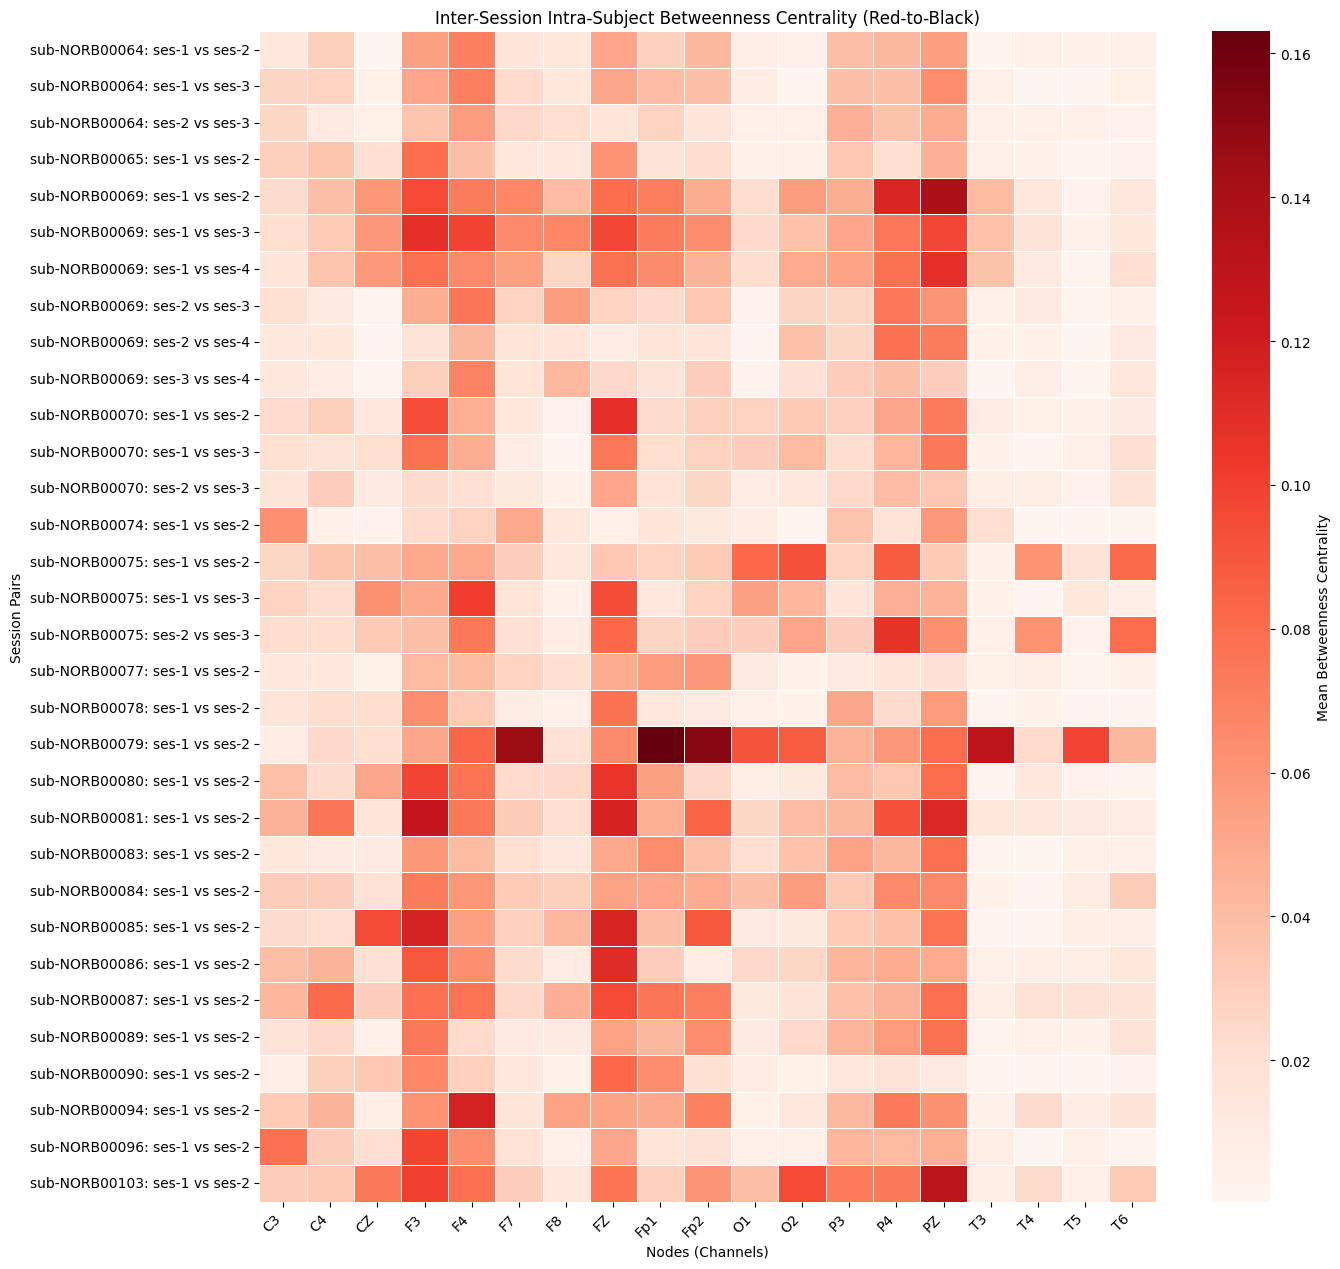

In [10]:
if not inter_session_intra_subject_jaccard_df.empty and not session_node_centrality_df.empty:
    heatmap_rows = []
    row_labels = []

    for _, row in inter_session_intra_subject_jaccard_df.iterrows():
        subject_id = row["subject_id"]
        session_a = row["session_a"]
        session_b = row["session_b"]

        sess_a_df = session_node_centrality_df[
            (session_node_centrality_df["subject_id"] == subject_id)
            & (session_node_centrality_df["session_id"] == session_a)
        ].set_index("node")["mean_betweenness_centrality"]

        sess_b_df = session_node_centrality_df[
            (session_node_centrality_df["subject_id"] == subject_id)
            & (session_node_centrality_df["session_id"] == session_b)
        ].set_index("node")["mean_betweenness_centrality"]

        aligned_nodes = sess_a_df.index.intersection(sess_b_df.index)
        avg_centrality = (sess_a_df[aligned_nodes] + sess_b_df[aligned_nodes]) / 2.0

        heatmap_rows.append(avg_centrality.values)
        row_labels.append(f"{subject_id}: {session_a} vs {session_b}")

    heatmap_matrix = np.array(heatmap_rows)
    col_labels = list(aligned_nodes)

    plt.figure(figsize=(14, max(8, len(heatmap_rows) * 0.4)))
    sns.heatmap(
        heatmap_matrix,
        xticklabels=col_labels,
        yticklabels=row_labels,
        cmap="Reds",
        cbar_kws={"label": "Mean Betweenness Centrality"},
        linewidths=0.5,
    )
    plt.title("Inter-Session Intra-Subject Betweenness Centrality (Red-to-Black)")
    plt.xlabel("Nodes (Channels)")
    plt.ylabel("Session Pairs")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for heatmap generation.")

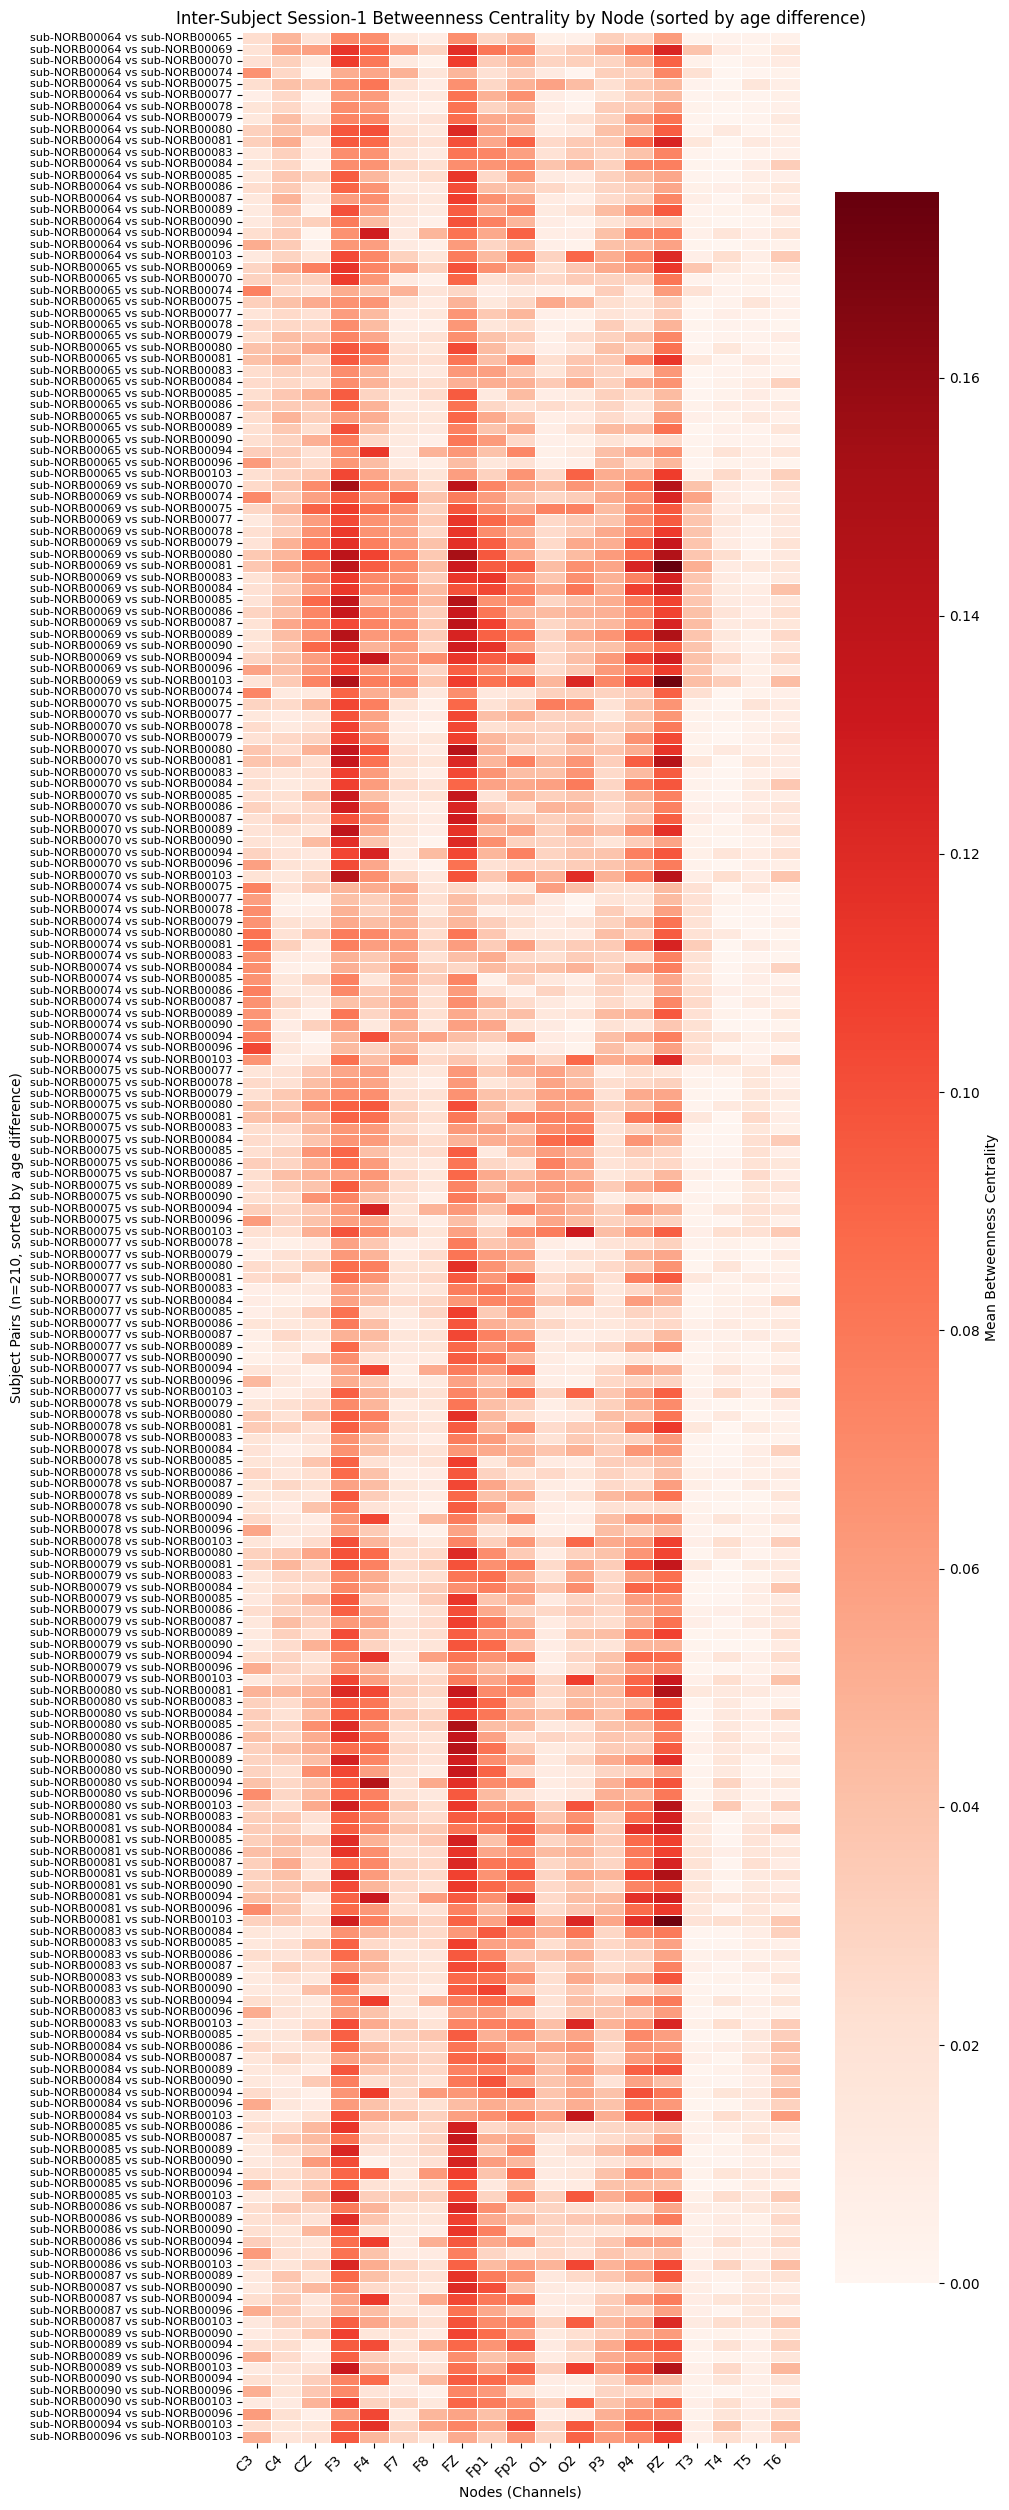

Session 1 subjects analyzed: 21
Subject pairs: 210
Nodes: 19
Sorted by age difference (smallest at bottom, largest at top)


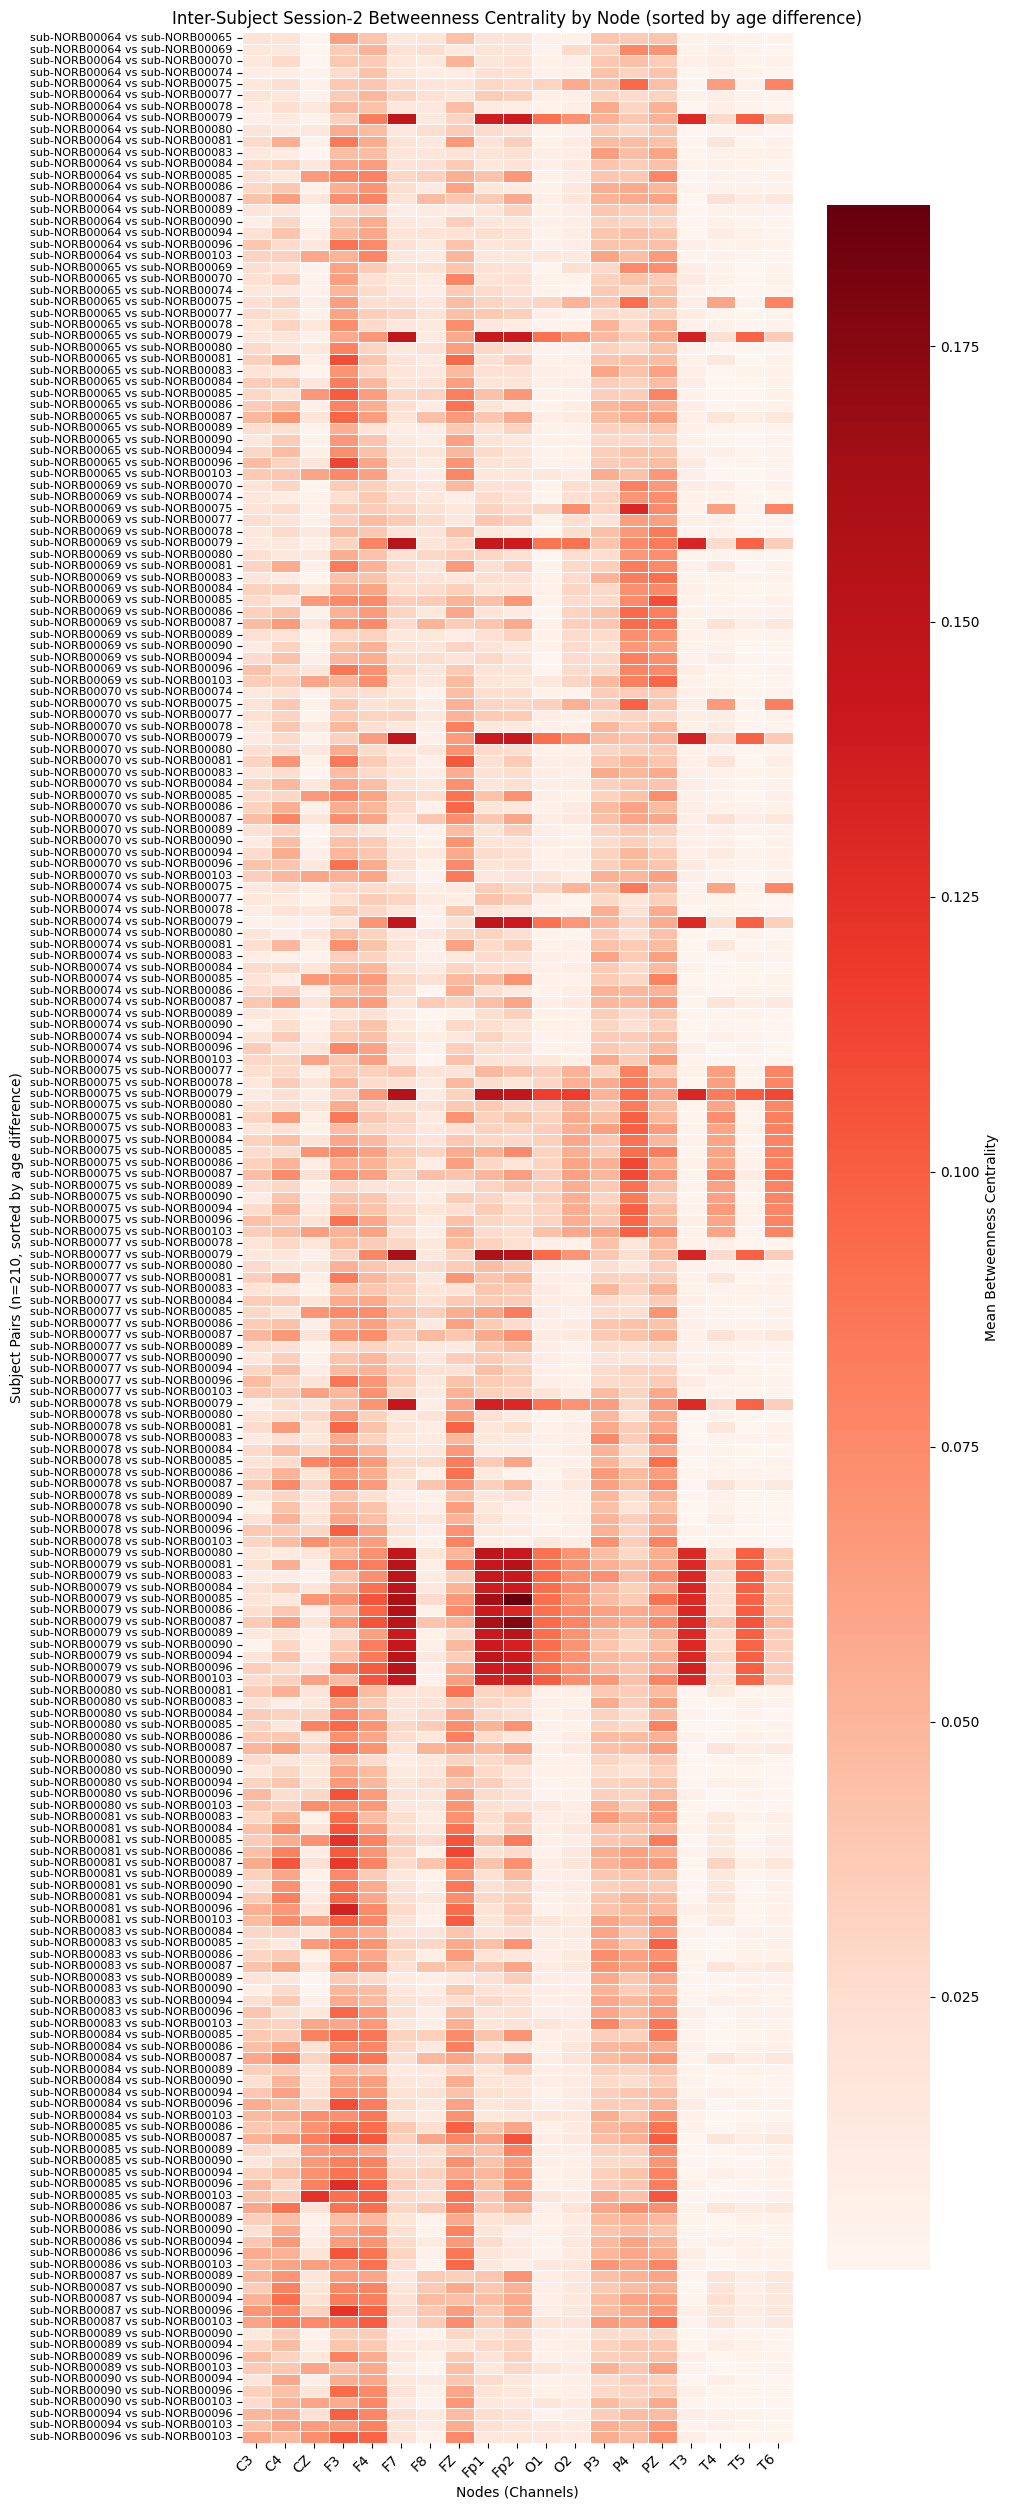

Session 2 subjects analyzed: 21
Subject pairs: 210
Nodes: 19
Sorted by age difference (smallest at bottom, largest at top)


In [11]:
if not session_node_centrality_df.empty:
    # Ensure subject_session_age is defined
    if 'subject_session_age' not in globals():
        subject_session_age = {}
    
    session_1_data = session_node_centrality_df[
        session_node_centrality_df["session_id"] == "ses-1"
    ]
    
    if not session_1_data.empty:
        subject_session_counts = session_node_centrality_df.groupby("subject_id")["session_id"].nunique()
        eligible_subjects = subject_session_counts[subject_session_counts >= 2].index

        session_1_subjects = sorted(
            session_1_data[session_1_data["subject_id"].isin(eligible_subjects)]["subject_id"].unique()
        )
        
        subject_vectors = {}
        for subject_id in session_1_subjects:
            subj_vector = (
                session_1_data[session_1_data["subject_id"] == subject_id]
                .set_index("node")["mean_betweenness_centrality"]
            )
            subject_vectors[subject_id] = subj_vector
        
        # Extract age information for subjects (if available)
        subject_ages = {}
        if subject_session_age:
            for subj in session_1_subjects:
                key = f"{subj}_ses-1"
                if key in subject_session_age:
                    subject_ages[subj] = subject_session_age[key]
        
        # Collect pair data with age differences for sorting
        pair_data = []
        for i, subject_a in enumerate(session_1_subjects):
            for j, subject_b in enumerate(session_1_subjects):
                if i < j:  # Only upper triangle to avoid duplicates
                    aligned = pd.concat(
                        [subject_vectors[subject_a], subject_vectors[subject_b]],
                        axis=1,
                        join="inner",
                    ).fillna(0.0)
                    aligned.columns = ["subject_a", "subject_b"]
                    
                    avg_centrality = (aligned["subject_a"] + aligned["subject_b"]) / 2.0
                    
                    # Calculate age difference if available
                    age_diff = None
                    if subject_a in subject_ages and subject_b in subject_ages:
                        try:
                            age_a = float(str(subject_ages[subject_a]).timestamp()) if hasattr(subject_ages[subject_a], 'timestamp') else float(subject_ages[subject_a])
                            age_b = float(str(subject_ages[subject_b]).timestamp()) if hasattr(subject_ages[subject_b], 'timestamp') else float(subject_ages[subject_b])
                            age_diff = abs(age_a - age_b)
                        except (ValueError, TypeError, AttributeError):
                            age_diff = float('inf')
                    else:
                        age_diff = float('inf')
                    
                    pair_data.append({
                        'subject_a': subject_a,
                        'subject_b': subject_b,
                        'centrality': avg_centrality.values,
                        'age_diff': age_diff,
                        'label': f"{subject_a} vs {subject_b}"
                    })
        
        # Sort by age difference (ascending)
        pair_data_sorted = sorted(pair_data, key=lambda x: x['age_diff'])
        
        heatmap_rows = [p['centrality'] for p in pair_data_sorted]
        row_labels = [p['label'] for p in pair_data_sorted]
        heatmap_matrix = np.array(heatmap_rows)
        col_labels = list(aligned.index)
        
        n_pairs = len(heatmap_rows)
        fig, ax = plt.subplots(figsize=(10, max(6, n_pairs * 0.12)))
        
        sns.heatmap(
            heatmap_matrix,
            xticklabels=col_labels,
            yticklabels=row_labels,
            cmap="Reds",
            cbar_kws={"label": "Mean Betweenness Centrality"},
            linewidths=0.5,
            ax=ax,
        )
        ax.set_title("Inter-Subject Session-1 Betweenness Centrality by Node (sorted by age difference)")
        ax.set_xlabel("Nodes (Channels)")
        ax.set_ylabel(f"Subject Pairs (n={n_pairs}, sorted by age difference)")
        ax.tick_params(axis="y", labelsize=8)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
        
        print(f"Session 1 subjects analyzed: {len(session_1_subjects)}")
        print(f"Subject pairs: {n_pairs}")
        print(f"Nodes: {len(col_labels)}")
        print(f"Sorted by age difference (smallest at bottom, largest at top)")
    else:
        print("No session-1 data available.")
else:
    print("No session-level centrality data available.")


if not session_node_centrality_df.empty:
    # Ensure subject_session_age is defined
    if 'subject_session_age' not in globals():
        subject_session_age = {}
    
    session_2_data = session_node_centrality_df[session_node_centrality_df["session_id"] == "ses-2"]

    if not session_2_data.empty:
        subject_session_counts = session_node_centrality_df.groupby("subject_id")["session_id"].nunique()
        eligible_subjects = subject_session_counts[subject_session_counts >= 2].index

        session_2_subjects = sorted(
            session_2_data[session_2_data["subject_id"].isin(eligible_subjects)]["subject_id"].unique()
        )

        subject_vectors = {}
        for subject_id in session_2_subjects:
            subj_vector = (
                session_2_data[session_2_data["subject_id"] == subject_id]
                .set_index("node")["mean_betweenness_centrality"]
            )
            subject_vectors[subject_id] = subj_vector

        # Extract age information for subjects (if available)
        subject_ages = {}
        if subject_session_age:
            for subj in session_2_subjects:
                key = f"{subj}_ses-2"
                if key in subject_session_age:
                    subject_ages[subj] = subject_session_age[key]
        
        # Collect pair data with age differences for sorting
        pair_data = []
        for i, subject_a in enumerate(session_2_subjects):
            for j, subject_b in enumerate(session_2_subjects):
                if i < j:  # Only upper triangle to avoid duplicates
                    aligned = pd.concat(
                        [subject_vectors[subject_a], subject_vectors[subject_b]],
                        axis=1,
                        join="inner",
                    ).fillna(0.0)
                    aligned.columns = ["subject_a", "subject_b"]

                    avg_centrality = (aligned["subject_a"] + aligned["subject_b"]) / 2.0
                    
                    # Calculate age difference if available
                    age_diff = None
                    if subject_a in subject_ages and subject_b in subject_ages:
                        try:
                            age_a = float(str(subject_ages[subject_a]).timestamp()) if hasattr(subject_ages[subject_a], 'timestamp') else float(subject_ages[subject_a])
                            age_b = float(str(subject_ages[subject_b]).timestamp()) if hasattr(subject_ages[subject_b], 'timestamp') else float(subject_ages[subject_b])
                            age_diff = abs(age_a - age_b)
                        except (ValueError, TypeError, AttributeError):
                            age_diff = float('inf')
                    else:
                        age_diff = float('inf')
                    
                    pair_data.append({
                        'subject_a': subject_a,
                        'subject_b': subject_b,
                        'centrality': avg_centrality.values,
                        'age_diff': age_diff,
                        'label': f"{subject_a} vs {subject_b}"
                    })
        
        # Sort by age difference (ascending)
        pair_data_sorted = sorted(pair_data, key=lambda x: x['age_diff'])
        
        heatmap_rows = [p['centrality'] for p in pair_data_sorted]
        row_labels = [p['label'] for p in pair_data_sorted]
        heatmap_matrix = np.array(heatmap_rows)
        col_labels = list(aligned.index)

        n_pairs = len(heatmap_rows)
        fig, ax = plt.subplots(figsize=(10, max(6, n_pairs * 0.12)))

        sns.heatmap(
            heatmap_matrix,
            xticklabels=col_labels,
            yticklabels=row_labels,
            cmap="Reds",
            cbar_kws={"label": "Mean Betweenness Centrality"},
            linewidths=0.5,
            ax=ax,
        )
        ax.set_title("Inter-Subject Session-2 Betweenness Centrality by Node (sorted by age difference)")
        ax.set_xlabel("Nodes (Channels)")
        ax.set_ylabel(f"Subject Pairs (n={n_pairs}, sorted by age difference)")
        ax.tick_params(axis="y", labelsize=8)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        print(f"Session 2 subjects analyzed: {len(session_2_subjects)}")
        print(f"Subject pairs: {n_pairs}")
        print(f"Nodes: {len(col_labels)}")
        print(f"Sorted by age difference (smallest at bottom, largest at top)")
    else:
        print("No session-2 data available.")
else:
    print("No session-level centrality data available.")

In [12]:
def extract_age_from_edf(edf_path):
    """Extract age or acquisition time from EDF file metadata."""
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
        # Try to get age from info
        if 'subject_info' in raw.info and raw.info['subject_info'] is not None:
            subject_info = raw.info['subject_info']
            if subject_info.get('age') is not None:
                return subject_info['age']
        # Try to get meas_date as fallback
        if raw.info['meas_date'] is not None:
            return raw.info['meas_date']
    except Exception as e:
        pass
    return None

# Build a mapping of subject_id + session_id to age/acquisition time
subject_session_age = {}
for subject_id in subjects:
    subject_edf_files = find_edf_files(subject_id)
    for edf_path in subject_edf_files:
        edf_name = Path(edf_path).stem
        parts = edf_name.split('_')
        session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-1'
        
        age = extract_age_from_edf(edf_path)
        if age is not None:
            key = f"{subject_id}_{session_id}"
            subject_session_age[key] = age

print(f"Extracted age/acquisition time for {len(subject_session_age)} subject-sessions")
if subject_session_age:
    print(f"Sample: {list(subject_session_age.items())[:3]}")


Extracted age/acquisition time for 130 subject-sessions
Sample: [('sub-NORB00001_ses-1', datetime.datetime(2023, 1, 1, 2, 0, 19, tzinfo=datetime.timezone.utc)), ('sub-NORB00002_ses-1', datetime.datetime(2023, 1, 1, 3, 2, 6, tzinfo=datetime.timezone.utc)), ('sub-NORB00003_ses-1', datetime.datetime(2023, 1, 1, 11, 33, 54, tzinfo=datetime.timezone.utc))]


In [13]:
if not session_node_centrality_df.empty and subject_session_age:
    # Create a list of (subject_id, session_id, age) tuples, filtering by those with age data
    subject_session_list = []
    for _, row in session_node_centrality_df.drop_duplicates(subset=['subject_id', 'session_id']).iterrows():
        key = f"{row['subject_id']}_{row['session_id']}"
        if key in subject_session_age:
            age = subject_session_age[key]
            subject_session_list.append((row['subject_id'], row['session_id'], age))
    
    # Sort by age
    subject_session_list_sorted = sorted(subject_session_list, key=lambda x: str(x[2]))
    
    print(f"Subject-sessions with age data: {len(subject_session_list_sorted)}")
    print("\nSorted subject-sessions by age:")
    for i, (subj, sess, age) in enumerate(subject_session_list_sorted[:10]):
        print(f"  {i+1}. {subj} {sess} -> Age: {age}")
    if len(subject_session_list_sorted) > 10:
        print(f"  ... and {len(subject_session_list_sorted) - 10} more")
    
    # Compute Jaccard similarity for adjacent subject-sessions
    adjacent_jaccard_rows = []
    
    for idx in range(len(subject_session_list_sorted) - 1):
        subj_a, sess_a, age_a = subject_session_list_sorted[idx]
        subj_b, sess_b, age_b = subject_session_list_sorted[idx + 1]
        
        # Get centrality vectors for both
        vector_a_df = session_node_centrality_df[
            (session_node_centrality_df['subject_id'] == subj_a) &
            (session_node_centrality_df['session_id'] == sess_a)
        ].set_index('node')['mean_betweenness_centrality']
        
        vector_b_df = session_node_centrality_df[
            (session_node_centrality_df['subject_id'] == subj_b) &
            (session_node_centrality_df['session_id'] == sess_b)
        ].set_index('node')['mean_betweenness_centrality']
        
        # Align vectors by common nodes
        aligned = pd.concat([vector_a_df, vector_b_df], axis=1, join='inner').fillna(0.0)
        if len(aligned) > 0:
            aligned.columns = ['vector_a', 'vector_b']
            
            jaccard_sim = weighted_jaccard_from_vectors(
                aligned['vector_a'].to_numpy(),
                aligned['vector_b'].to_numpy()
            )
            
            adjacent_jaccard_rows.append({
                'subject_a': subj_a,
                'session_a': sess_a,
                'age_a': str(age_a),
                'subject_b': subj_b,
                'session_b': sess_b,
                'age_b': str(age_b),
                'jaccard_index': jaccard_sim,
                'n_nodes': len(aligned)
            })
    
    adjacent_jaccard_df = pd.DataFrame(adjacent_jaccard_rows)
    
    print(f"\n✓ Computed Jaccard indices for {len(adjacent_jaccard_df)} adjacent subject-session pairs")
    if not adjacent_jaccard_df.empty:
        print(f"\nFirst 10 adjacent pairs:")
        display(adjacent_jaccard_df.head(10))
        print(f"\nJaccard similarity statistics:")
        print(f"  Mean: {adjacent_jaccard_df['jaccard_index'].mean():.4f}")
        print(f"  Std: {adjacent_jaccard_df['jaccard_index'].std():.4f}")
        print(f"  Min: {adjacent_jaccard_df['jaccard_index'].min():.4f}")
        print(f"  Max: {adjacent_jaccard_df['jaccard_index'].max():.4f}")
else:
    print("Insufficient data: session_node_centrality_df or subject_session_age data not available.")


Subject-sessions with age data: 125

Sorted subject-sessions by age:
  1. sub-NORB00082 ses-1 -> Age: 2023-01-01 00:11:52+00:00
  2. sub-NORB00016 ses-1 -> Age: 2023-01-01 00:14:17+00:00
  3. sub-NORB00095 ses-1 -> Age: 2023-01-01 00:18:47+00:00
  4. sub-NORB00068 ses-1 -> Age: 2023-01-01 00:39:36+00:00
  5. sub-NORB00065 ses-2 -> Age: 2023-01-01 00:40:30+00:00
  6. sub-NORB00023 ses-1 -> Age: 2023-01-01 00:52:51+00:00
  7. sub-NORB00089 ses-1 -> Age: 2023-01-01 01:09:41+00:00
  8. sub-NORB00069 ses-1 -> Age: 2023-01-01 01:19:46+00:00
  9. sub-NORB00014 ses-1 -> Age: 2023-01-01 01:24:19+00:00
  10. sub-NORB00094 ses-1 -> Age: 2023-01-01 01:31:10+00:00
  ... and 115 more

✓ Computed Jaccard indices for 124 adjacent subject-session pairs

First 10 adjacent pairs:


,subject_a,session_a,age_a,subject_b,session_b,age_b,jaccard_index,n_nodes
0,sub-NORB00082,ses-1,2023-01-01 00:11:52+00:00,sub-NORB00016,ses-1,2023-01-01 00:14:17+00:00,0.452138,19
1,sub-NORB00016,ses-1,2023-01-01 00:14:17+00:00,sub-NORB00095,ses-1,2023-01-01 00:18:47+00:00,0.555851,19
2,sub-NORB00095,ses-1,2023-01-01 00:18:47+00:00,sub-NORB00068,ses-1,2023-01-01 00:39:36+00:00,0.550755,19
3,sub-NORB00068,ses-1,2023-01-01 00:39:36+00:00,sub-NORB00065,ses-2,2023-01-01 00:40:30+00:00,0.540115,19
4,sub-NORB00065,ses-2,2023-01-01 00:40:30+00:00,sub-NORB00023,ses-1,2023-01-01 00:52:51+00:00,0.476479,19
5,sub-NORB00023,ses-1,2023-01-01 00:52:51+00:00,sub-NORB00089,ses-1,2023-01-01 01:09:41+00:00,0.445966,19
6,sub-NORB00089,ses-1,2023-01-01 01:09:41+00:00,sub-NORB00069,ses-1,2023-01-01 01:19:46+00:00,0.529506,19
7,sub-NORB00069,ses-1,2023-01-01 01:19:46+00:00,sub-NORB00014,ses-1,2023-01-01 01:24:19+00:00,0.253022,19
8,sub-NORB00014,ses-1,2023-01-01 01:24:19+00:00,sub-NORB00094,ses-1,2023-01-01 01:31:10+00:00,0.354906,19
9,sub-NORB00094,ses-1,2023-01-01 01:31:10+00:00,sub-NORB00103,ses-1,2023-01-01 01:46:18+00:00,0.496957,19



Jaccard similarity statistics:
  Mean: 0.4231
  Std: 0.1103
  Min: 0.1509
  Max: 0.6914


/tmp/ipykernel_22774/386244985.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


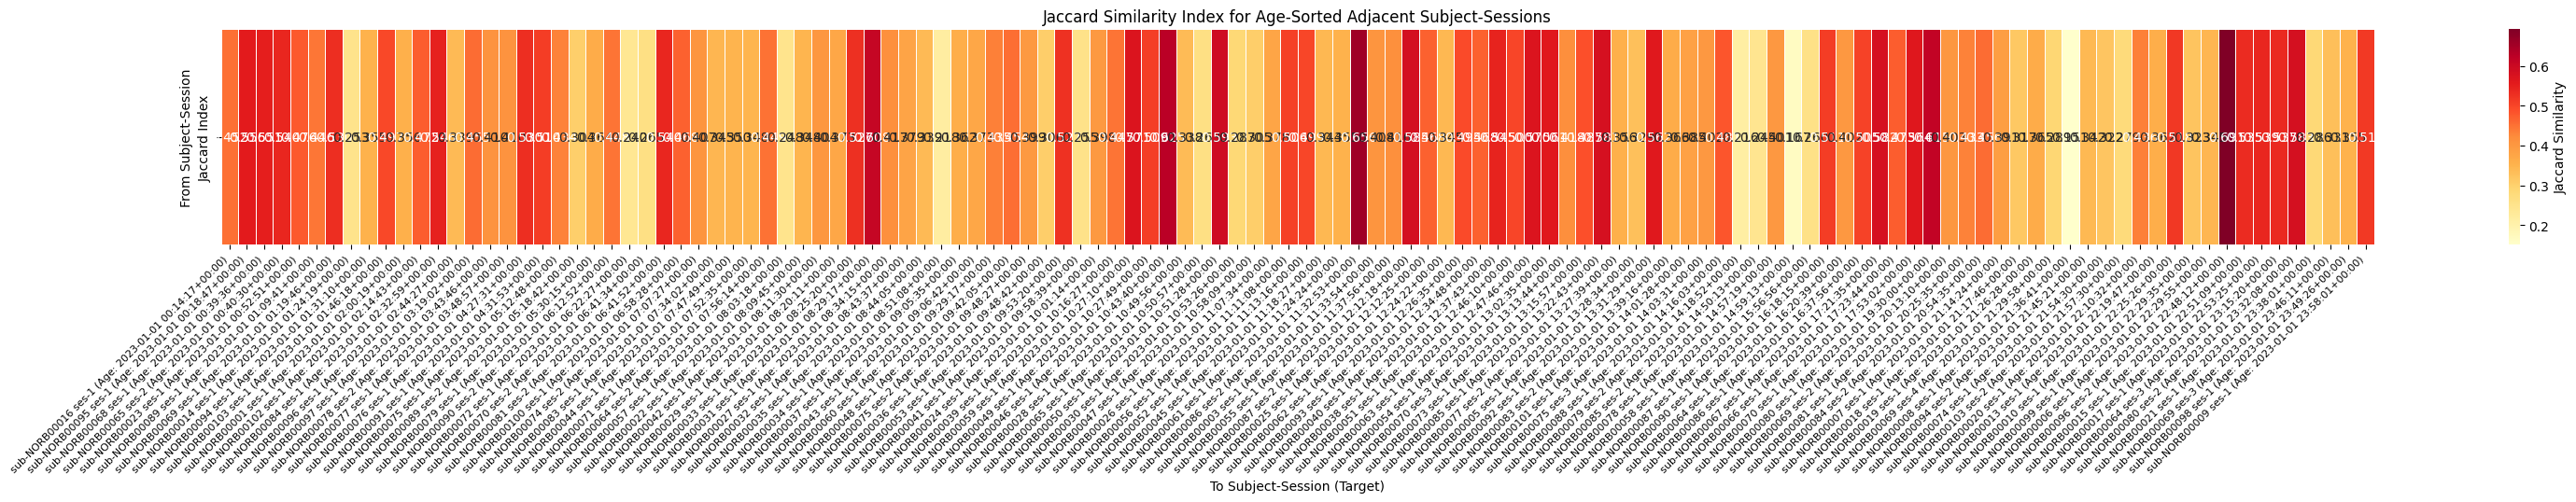

✓ Heatmap generated for 124 adjacent subject-session pairs


In [14]:
if not adjacent_jaccard_df.empty:
    # Create labels for the heatmap
    y_labels = [f"{row['subject_a']} {row['session_a']} (Age: {row['age_a']})" 
                for _, row in adjacent_jaccard_df.iterrows()]
    x_labels = [f"{row['subject_b']} {row['session_b']} (Age: {row['age_b']})" 
                for _, row in adjacent_jaccard_df.iterrows()]
    
    # Create a matrix from the adjacent pairs
    # Each row is a pair, so we create a simple N x 2 matrix where column 0 is the pair index
    # and column 1 is the Jaccard value, then visualize as a heatmap
    heatmap_data = adjacent_jaccard_df[['jaccard_index']].T.values
    
    n_pairs = len(adjacent_jaccard_df)
    fig, ax = plt.subplots(figsize=(max(12, n_pairs * 0.3), 3))
    
    sns.heatmap(
        heatmap_data,
        xticklabels=x_labels,
        yticklabels=['Jaccard Index'],
        cmap='YlOrRd',
        cbar_kws={'label': 'Jaccard Similarity'},
        linewidths=0.5,
        ax=ax,
        annot=adjacent_jaccard_df[['jaccard_index']].T.values,
        fmt='.3f',
    )
    ax.set_title('Jaccard Similarity Index for Age-Sorted Adjacent Subject-Sessions')
    ax.set_xlabel('To Subject-Session (Target)')
    ax.set_ylabel('From Subject-Session')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Heatmap generated for {n_pairs} adjacent subject-session pairs")
else:
    print("No adjacent Jaccard data available for heatmap visualization.")


In [15]:
# Compute edge betweenness per subject-session and inter-subject intra-session Jaccard
from itertools import combinations

# If we don't have pairwise data, exit with a message
if all_segment_pairwise_df.empty:
    print("No pairwise segment data (all_segment_pairwise_df) available to compute edge betweenness.")
else:
    # Build canonical node list (expected ~19 electrodes) from pairwise data or session node df
    nodes = sorted(pd.unique(all_segment_pairwise_df[['node_i', 'node_j']].values.ravel()))
    edges = [tuple(sorted(e)) for e in combinations(nodes, 2)]

    # Aggregate mean distance per edge for each subject-session across segments
    agg = (
        all_segment_pairwise_df
        .assign(u=lambda df: df.apply(lambda r: sorted([r['node_i'], r['node_j']])[0], axis=1),
                v=lambda df: df.apply(lambda r: sorted([r['node_i'], r['node_j']])[1], axis=1))
        .groupby(['subject_id', 'session_id', 'u', 'v'], as_index=False)['distance']
        .mean()
        .rename(columns={'u':'node_i','v':'node_j'})
    )

    # Build edge distance mapping per subject-session and compute edge betweenness using NetworkX
    ss_groups = agg.groupby(['subject_id', 'session_id'])
    ss_edge_vectors = {}
    for (subj, sess), grp in ss_groups:
        # map distances keyed by sorted edge tuple
        dmap = {tuple(sorted([row['node_i'], row['node_j']])): row['distance'] for _, row in grp.iterrows()}

        # Build graph with nodes and available weighted edges (distance = small => close).
        G = nx.Graph()
        G.add_nodes_from(nodes)
        for (u, v) in edges:
            w = dmap.get((u, v), None)
            if w is not None and np.isfinite(w):
                # NetworkX treats 'weight' as cost for shortest paths (Dijkstra).
                G.add_edge(u, v, weight=float(w))

        # Compute edge betweenness centrality (weighted). Missing edges default to 0.0 in the vector.
        eb = nx.edge_betweenness_centrality(G, weight='weight', normalized=True)

        # Align vector to canonical edges order
        vec = np.array([eb.get((u, v), eb.get((v, u), 0.0)) for (u, v) in edges], dtype=float)
        ss_edge_vectors[(subj, sess)] = vec

    # Build DataFrame of edge betweenness values
    rows = []
    for (subj, sess), vec in ss_edge_vectors.items():
        for idx, (u, v) in enumerate(edges):
            rows.append({
                'subject_id': subj,
                'session_id': sess,
                'edge': f'{u}|{v}',
                'edge_index': idx,
                'edge_betweenness': float(vec[idx]),
            })
    edge_betweenness_df = pd.DataFrame(rows)

    print(f"Computed edge betweenness for {len(ss_edge_vectors)} subject-sessions and {len(edges)} edges.")
    display(edge_betweenness_df.head())

    # Compute inter-subject, intra-session Jaccard similarity using min/max weighted Jaccard on edge betweenness vectors
    jaccard_rows = []
    for sess in sorted(edge_betweenness_df['session_id'].unique()):
        sess_df = edge_betweenness_df[edge_betweenness_df['session_id'] == sess]
        subjects = sorted(sess_df['subject_id'].unique())
        if len(subjects) < 2:
            continue

        # create aligned vectors per subject (ordered by edge_index)
        subj_vectors = {}
        for subj in subjects:
            v = (sess_df[sess_df['subject_id'] == subj].sort_values('edge_index')['edge_betweenness'].to_numpy())
            # ensure non-negative (should be non-negative already)
            subj_vectors[subj] = np.maximum(v, 0.0)

        # pairwise jaccard within this session
        for i in range(len(subjects)):
            for j in range(i + 1, len(subjects)):
                a = subjects[i]
                b = subjects[j]
                va = subj_vectors[a]
                vb = subj_vectors[b]
                # use existing weighted_jaccard_from_vectors (min/max approach)
                jidx = weighted_jaccard_from_vectors(va, vb)
                jaccard_rows.append({
                    'session_id': sess,
                    'subject_a': a,
                    'subject_b': b,
                    'jaccard_index': float(jidx),
                })

    inter_subject_intra_session_jaccard_df = pd.DataFrame(jaccard_rows)
    print(f"Computed inter-subject intra-session Jaccard rows: {len(inter_subject_intra_session_jaccard_df)}")
    if not inter_subject_intra_session_jaccard_df.empty:
        display(inter_subject_intra_session_jaccard_df.head())
    else:
        print("No inter-subject intra-session pairs available to compute Jaccard.")

Computed edge betweenness for 125 subject-sessions and 171 edges.


,subject_id,session_id,edge,edge_index,edge_betweenness
0,sub-NORB00001,ses-1,C3|C4,0,0.005848
1,sub-NORB00001,ses-1,C3|CZ,1,0.005848
2,sub-NORB00001,ses-1,C3|F3,2,0.011696
3,sub-NORB00001,ses-1,C3|F4,3,0.005848
4,sub-NORB00001,ses-1,C3|F7,4,0.005848


Computed inter-subject intra-session Jaccard rows: 5067


,session_id,subject_a,subject_b,jaccard_index
0,ses-1,sub-NORB00001,sub-NORB00003,0.176221
1,ses-1,sub-NORB00001,sub-NORB00005,0.349854
2,ses-1,sub-NORB00001,sub-NORB00006,0.549242
3,ses-1,sub-NORB00001,sub-NORB00007,0.443262
4,ses-1,sub-NORB00001,sub-NORB00008,0.326705


In [16]:
# Summary statistics: mean betweenness centrality for all nodes and edges across all subjects
print("="*80)
print("SUMMARY STATISTICS: Mean Betweenness Centrality Across All Subjects")
print("="*80)

# Node-level summary
if not session_node_centrality_df.empty:
    print("\n### NODE-LEVEL BETWEENNESS CENTRALITY ###\n")
    
    node_summary = session_node_centrality_df.groupby('node')['mean_betweenness_centrality'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max'),
        ('count', 'count')
    ]).round(6)
    
    node_summary = node_summary.sort_values('mean', ascending=False)
    print(node_summary)
    print(f"\nTotal nodes analyzed: {len(node_summary)}")
    print(f"Overall mean (all nodes): {session_node_centrality_df['mean_betweenness_centrality'].mean():.6f}")
    print(f"Overall std (all nodes): {session_node_centrality_df['mean_betweenness_centrality'].std():.6f}")
    print(f"Overall min: {session_node_centrality_df['mean_betweenness_centrality'].min():.6f}")
    print(f"Overall max: {session_node_centrality_df['mean_betweenness_centrality'].max():.6f}")
else:
    print("No node-level centrality data available.")

# Edge-level summary
if 'edge_betweenness_df' in globals() and not edge_betweenness_df.empty:
    print("\n" + "="*80)
    print("### EDGE-LEVEL BETWEENNESS CENTRALITY ###\n")
    
    edge_summary = edge_betweenness_df.groupby('edge')['edge_betweenness'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max'),
        ('count', 'count')
    ]).round(6)
    
    edge_summary = edge_summary.sort_values('mean', ascending=False)
    print(edge_summary)
    print(f"\nTotal edges analyzed: {len(edge_summary)}")
    print(f"Overall mean (all edges): {edge_betweenness_df['edge_betweenness'].mean():.6f}")
    print(f"Overall std (all edges): {edge_betweenness_df['edge_betweenness'].std():.6f}")
    print(f"Overall min: {edge_betweenness_df['edge_betweenness'].min():.6f}")
    print(f"Overall max: {edge_betweenness_df['edge_betweenness'].max():.6f}")
else:
    print("No edge-level centrality data available.")

# Session summary
if not session_node_centrality_df.empty:
    print("\n" + "="*80)
    print("### SUMMARY BY SESSION ###\n")
    
    session_summary = session_node_centrality_df.groupby('session_id')['mean_betweenness_centrality'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('count', 'count')
    ]).round(6)
    
    print(session_summary)

# Subject summary
if not session_node_centrality_df.empty:
    print("\n" + "="*80)
    print("### TOP 10 SUBJECTS BY MEAN BETWEENNESS CENTRALITY ###\n")
    
    subject_summary = session_node_centrality_df.groupby('subject_id')['mean_betweenness_centrality'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('count', 'count')
    ]).round(6)
    
    subject_summary = subject_summary.sort_values('mean', ascending=False)
    print(subject_summary.head(10))

print("\n" + "="*80)

SUMMARY STATISTICS: Mean Betweenness Centrality Across All Subjects

### NODE-LEVEL BETWEENNESS CENTRALITY ###

          mean       std       min       max  count
node                                               
FZ    0.080046  0.057436  0.004248  0.288958    125
F3    0.078558  0.049618  0.000000  0.343791    125
PZ    0.074278  0.050631  0.001307  0.245643    125
F4    0.073119  0.047707  0.001743  0.327141    125
P4    0.063699  0.050522  0.005482  0.276230    125
C3    0.055871  0.056166  0.000980  0.370196    125
P3    0.054911  0.037288  0.003595  0.246187    125
Fp1   0.051222  0.036926  0.000000  0.260784    125
Fp2   0.050099  0.037724  0.000000  0.259150    125
C4    0.050062  0.050791  0.004248  0.289090    125
CZ    0.047930  0.061370  0.000000  0.276416    125
O2    0.028590  0.034695  0.000000  0.176284    125
F7    0.027197  0.028772  0.001634  0.276471    125
F8    0.026148  0.032360  0.000000  0.287582    125
O1    0.022677  0.031097  0.000000  0.225218    125
T6  

In [17]:
# Helper functions for brain region categorization
def get_electrode_region(elec_name):
    """Categorize electrode by brain region."""
    name_upper = elec_name.upper().strip()
    if name_upper.startswith('FP'):
        return 'FP'
    elif name_upper.startswith('F'):
        return 'Frontal'
    elif name_upper.startswith('C'):
        return 'Central'
    elif name_upper.startswith('P'):
        return 'Parietal'
    elif name_upper.startswith('O'):
        return 'Occipital'
    elif name_upper.startswith('T'):
        return 'Temporal'
    else:
        return 'Other'



def get_edge_region_pair(edge_str):
    """Extract region pair from edge string or tuple."""
    # Handle both string and tuple formats
    if isinstance(edge_str, tuple):
        e1, e2 = edge_str[0], edge_str[1]
    else:
        parts = edge_str.split('|')
        if len(parts) != 2:
            return 'XX'
        e1, e2 = parts[0].strip(), parts[1].strip()
    
    r1 = get_electrode_region(e1)
    r2 = get_electrode_region(e2)
    
    region_abbr = {
        'FP': 'F',
        'Frontal': 'F',
        'Central': 'C',
        'Temporal': 'T',
        'Parietal': 'P',
        'Occipital': 'O',
        'Other': 'X'
    }
    
    r1_letter = region_abbr.get(r1, 'X')
    r2_letter = region_abbr.get(r2, 'X')
    
    pair = ''.join(sorted([r1_letter, r2_letter]))
    return pair



def get_edge_region_pair_order(edge_str, pair_order=['FF', 'FC', 'FT', 'FP', 'FO', 'CC', 'CT', 'CP', 'CO', 'TT', 'TP', 'TO', 'PP', 'PO', 'OO']):
    """Return the sort order index for an edge based on its region pair."""
    pair = get_edge_region_pair(edge_str)
    try:
        return pair_order.index(pair)
    except ValueError:
        # If pair not in standard order, place it at the end
        return len(pair_order)



def add_region_cluster_labels(ax, edges, pair_order=['FF', 'FC', 'FT', 'FP', 'FO', 'CC', 'CT', 'CP', 'CO', 'TT', 'TP', 'TO', 'PP', 'PO', 'OO']):
    """Add region pair cluster labels above the heatmap x-axis."""
    # Convert edges to strings for consistent handling
    edges_list = []
    for e in edges:
        if isinstance(e, tuple):
            edges_list.append(f"{e[0]}|{e[1]}")
        else:
            edges_list.append(str(e))
    
    # Group edges by region pair and track positions
    region_clusters = {}
    for idx, edge in enumerate(edges_list):
        region = get_edge_region_pair(edge)
        if region not in region_clusters:
            region_clusters[region] = {'start': idx, 'end': idx, 'count': 0}
        region_clusters[region]['end'] = idx
        region_clusters[region]['count'] += 1
    
    # Get x-axis limits and figure width
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Add labels for each region pair cluster
    for region in pair_order:
        if region in region_clusters:
            cluster = region_clusters[region]
            start_pos = cluster['start']
            end_pos = cluster['end']
            count = cluster['count']
            
            # Calculate center position and percentage
            center = (start_pos + end_pos) / 2.0 + 0.5
            percentage = (count / len(edges_list)) * 100
            
            # Add text label above the heatmap
            ax.text(center, ylim[1] + (ylim[1] - ylim[0]) * 0.02,
                   f"{region}\n({percentage:.1f}%)",
                   ha='center', va='bottom', fontsize=13, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            
            # Add vertical lines to separate clusters
            if end_pos < len(edges_list) - 1:
                ax.axvline(x=end_pos + 1, color='black', linestyle='-', linewidth=1.5, alpha=0.5)

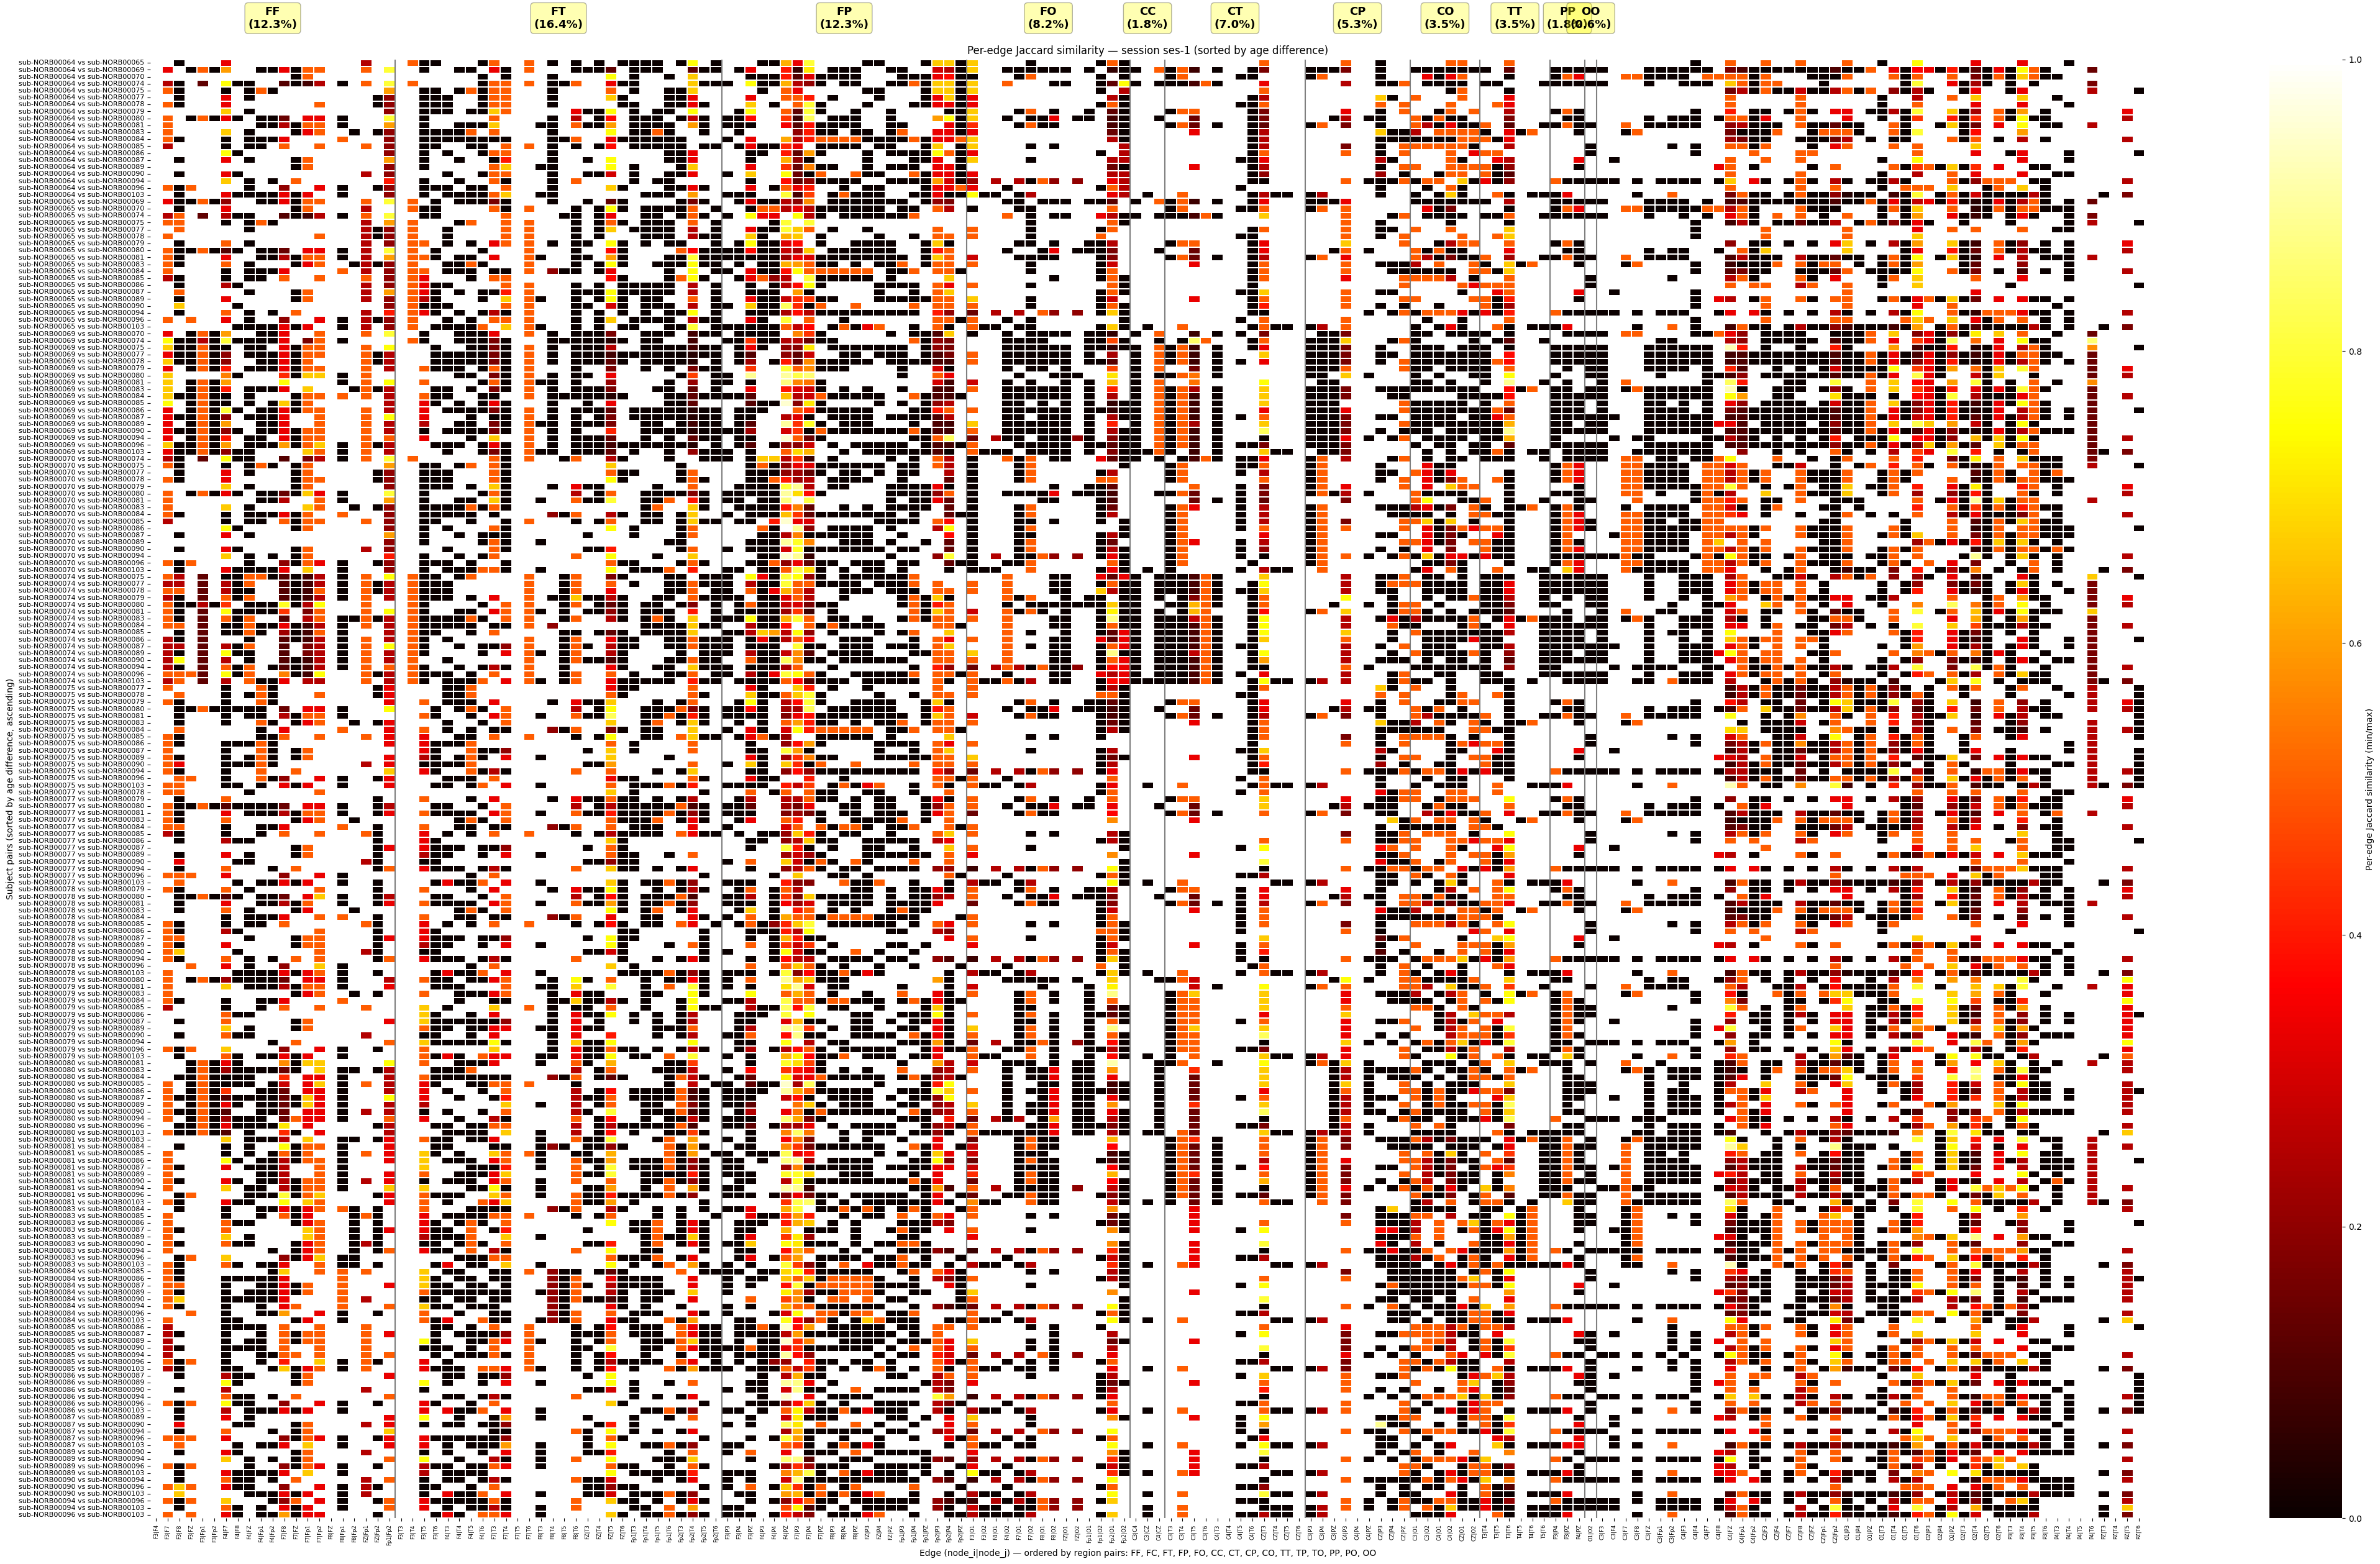

Heatmap plotted: 210 subject pairs × 171 edges.
Sorted by age difference (smallest at bottom, largest at top).
Edge pairs ordered as: FF, FC, FT, FP, FO, CC, CT, CP, CO, TT, TP, TO, PP, PO, OO


In [22]:
# Ensure subject_session_age is defined
if 'subject_session_age' not in globals():
    subject_session_age = {}

# This cell builds a per-edge similarity matrix between subject pairs and plots a heatmap
if 'edge_betweenness_df' not in globals() or edge_betweenness_df.empty:
    print("edge_betweenness_df not found or empty. Run the previous cell first.")
else:
    session_sel = 'ses-1'
    sess_df = edge_betweenness_df[edge_betweenness_df['session_id'] == session_sel]

    # Identify subjects with >=2 sessions (use session_node_centrality_df if available)
    if 'session_node_centrality_df' in globals() and not session_node_centrality_df.empty:
        subj_counts = session_node_centrality_df.groupby('subject_id')['session_id'].nunique()
        eligible_subjects = subj_counts[subj_counts >= 2].index.tolist()
    else:
        eligible_subjects = []

    subjects = sorted(sess_df[sess_df['subject_id'].isin(eligible_subjects)]['subject_id'].unique())
    if len(subjects) < 2:
        print(f"No eligible subjects with >=2 sessions for {session_sel} (found {len(subjects)}).")
    else:
        # Sort edges by region pair ordering: FF, FC, FT, FP, FO, CC, CT, CP, CO, TT, TP, TO, PP, PO, OO
        all_edges = list(edge_betweenness_df.sort_values('edge_index')['edge'].drop_duplicates())
        edges = sorted(all_edges, key=get_edge_region_pair_order)

        # build aligned vectors per subject (length = n_edges)
        subj_vectors = {}
        for subj in subjects:
            subdf = sess_df[sess_df['subject_id'] == subj]
            if len(subdf) == len(edges):
                v = subdf.sort_values('edge_index')['edge_betweenness'].to_numpy()
            else:
                # align by edge label, fill missing with 0.0
                tmp = pd.Series(0.0, index=edges)
                s = subdf.set_index('edge')['edge_betweenness'] if not subdf.empty else pd.Series(dtype=float)
                for e, val in s.items():
                    if e in tmp.index:
                        tmp.at[e] = val
                v = tmp.to_numpy()
            subj_vectors[subj] = np.maximum(v, 0.0)

        # Extract age information for subjects (if available)
        subject_ages = {}
        if subject_session_age:
            for subj in subjects:
                key = f"{subj}_{session_sel}"
                if key in subject_session_age:
                    subject_ages[subj] = subject_session_age[key]
        
        # compute per-edge similarity for each subject pair: min/max per edge (define 1.0 when both zero)
        # Initialize pair_data fresh to avoid stale data from previous runs
        pair_data = []
        for i in range(len(subjects)):
            for j in range(i + 1, len(subjects)):
                a = subjects[i]
                b = subjects[j]
                va = subj_vectors[a]
                vb = subj_vectors[b]
                denom = np.maximum(va, vb)
                sim = np.zeros_like(va)
                both_zero = denom == 0
                sim[both_zero] = 1.0
                nz = ~both_zero
                sim[nz] = np.minimum(va[nz], vb[nz]) / denom[nz]
                
                # Calculate age difference if available
                age_diff = None
                if a in subject_ages and b in subject_ages:
                    try:
                        age_a = float(str(subject_ages[a]).timestamp()) if hasattr(subject_ages[a], 'timestamp') else float(subject_ages[a])
                        age_b = float(str(subject_ages[b]).timestamp()) if hasattr(subject_ages[b], 'timestamp') else float(subject_ages[b])
                        age_diff = abs(age_a - age_b)
                    except (ValueError, TypeError, AttributeError):
                        age_diff = float('inf')  # Subjects without age go to end
                else:
                    age_diff = float('inf')
                
                pair_data.append({
                    'subject_a': a,
                    'subject_b': b,
                    'similarity': sim,
                    'age_diff': age_diff,
                    'label': f"{a} vs {b}"
                })
        
        # Sort by age difference (ascending)
        pair_data_sorted = sorted(pair_data, key=lambda x: x['age_diff'])
        
        pair_labels = [p['label'] for p in pair_data_sorted]
        heatmap_rows = [p['similarity'] for p in pair_data_sorted]
        heatmap_matrix = np.array(heatmap_rows)

        # Plot heatmap
        plt.figure(figsize=(max(20, len(edges) * 0.25), max(4, heatmap_matrix.shape[0] * 0.12)))
        ax = sns.heatmap(
            heatmap_matrix,
            xticklabels=edges,
            yticklabels=pair_labels,
            cmap='hot',
            vmin=0.0, vmax=1.0,
            cbar_kws={'label': 'Per-edge Jaccard similarity (min/max)'},
            linewidths=0.2,
        )
        
        # Add region pair cluster labels
        add_region_cluster_labels(ax, edges)
        
        plt.title(f"Per-edge Jaccard similarity — session {session_sel} (sorted by age difference)")
        plt.xlabel('Edge (node_i|node_j) — ordered by region pairs: FF, FC, FT, FP, FO, CC, CT, CP, CO, TT, TP, TO, PP, PO, OO')
        plt.ylabel('Subject pairs (sorted by age difference, ascending)')
        plt.xticks(rotation=90, fontsize=6)
        plt.yticks(fontsize=8)
        plt.tight_layout()

        output_dir = Path("heatmap_outputs")
        output_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_dir / f"per_edge_jaccard_similarity_{session_sel}.png", dpi=300, bbox_inches="tight")
        plt.show()

        print(f"Heatmap plotted: {heatmap_matrix.shape[0]} subject pairs × {heatmap_matrix.shape[1]} edges.")
        print(f"Sorted by age difference (smallest at bottom, largest at top).")
        print(f"Edge pairs ordered as: FF, FC, FT, FP, FO, CC, CT, CP, CO, TT, TP, TO, PP, PO, OO")

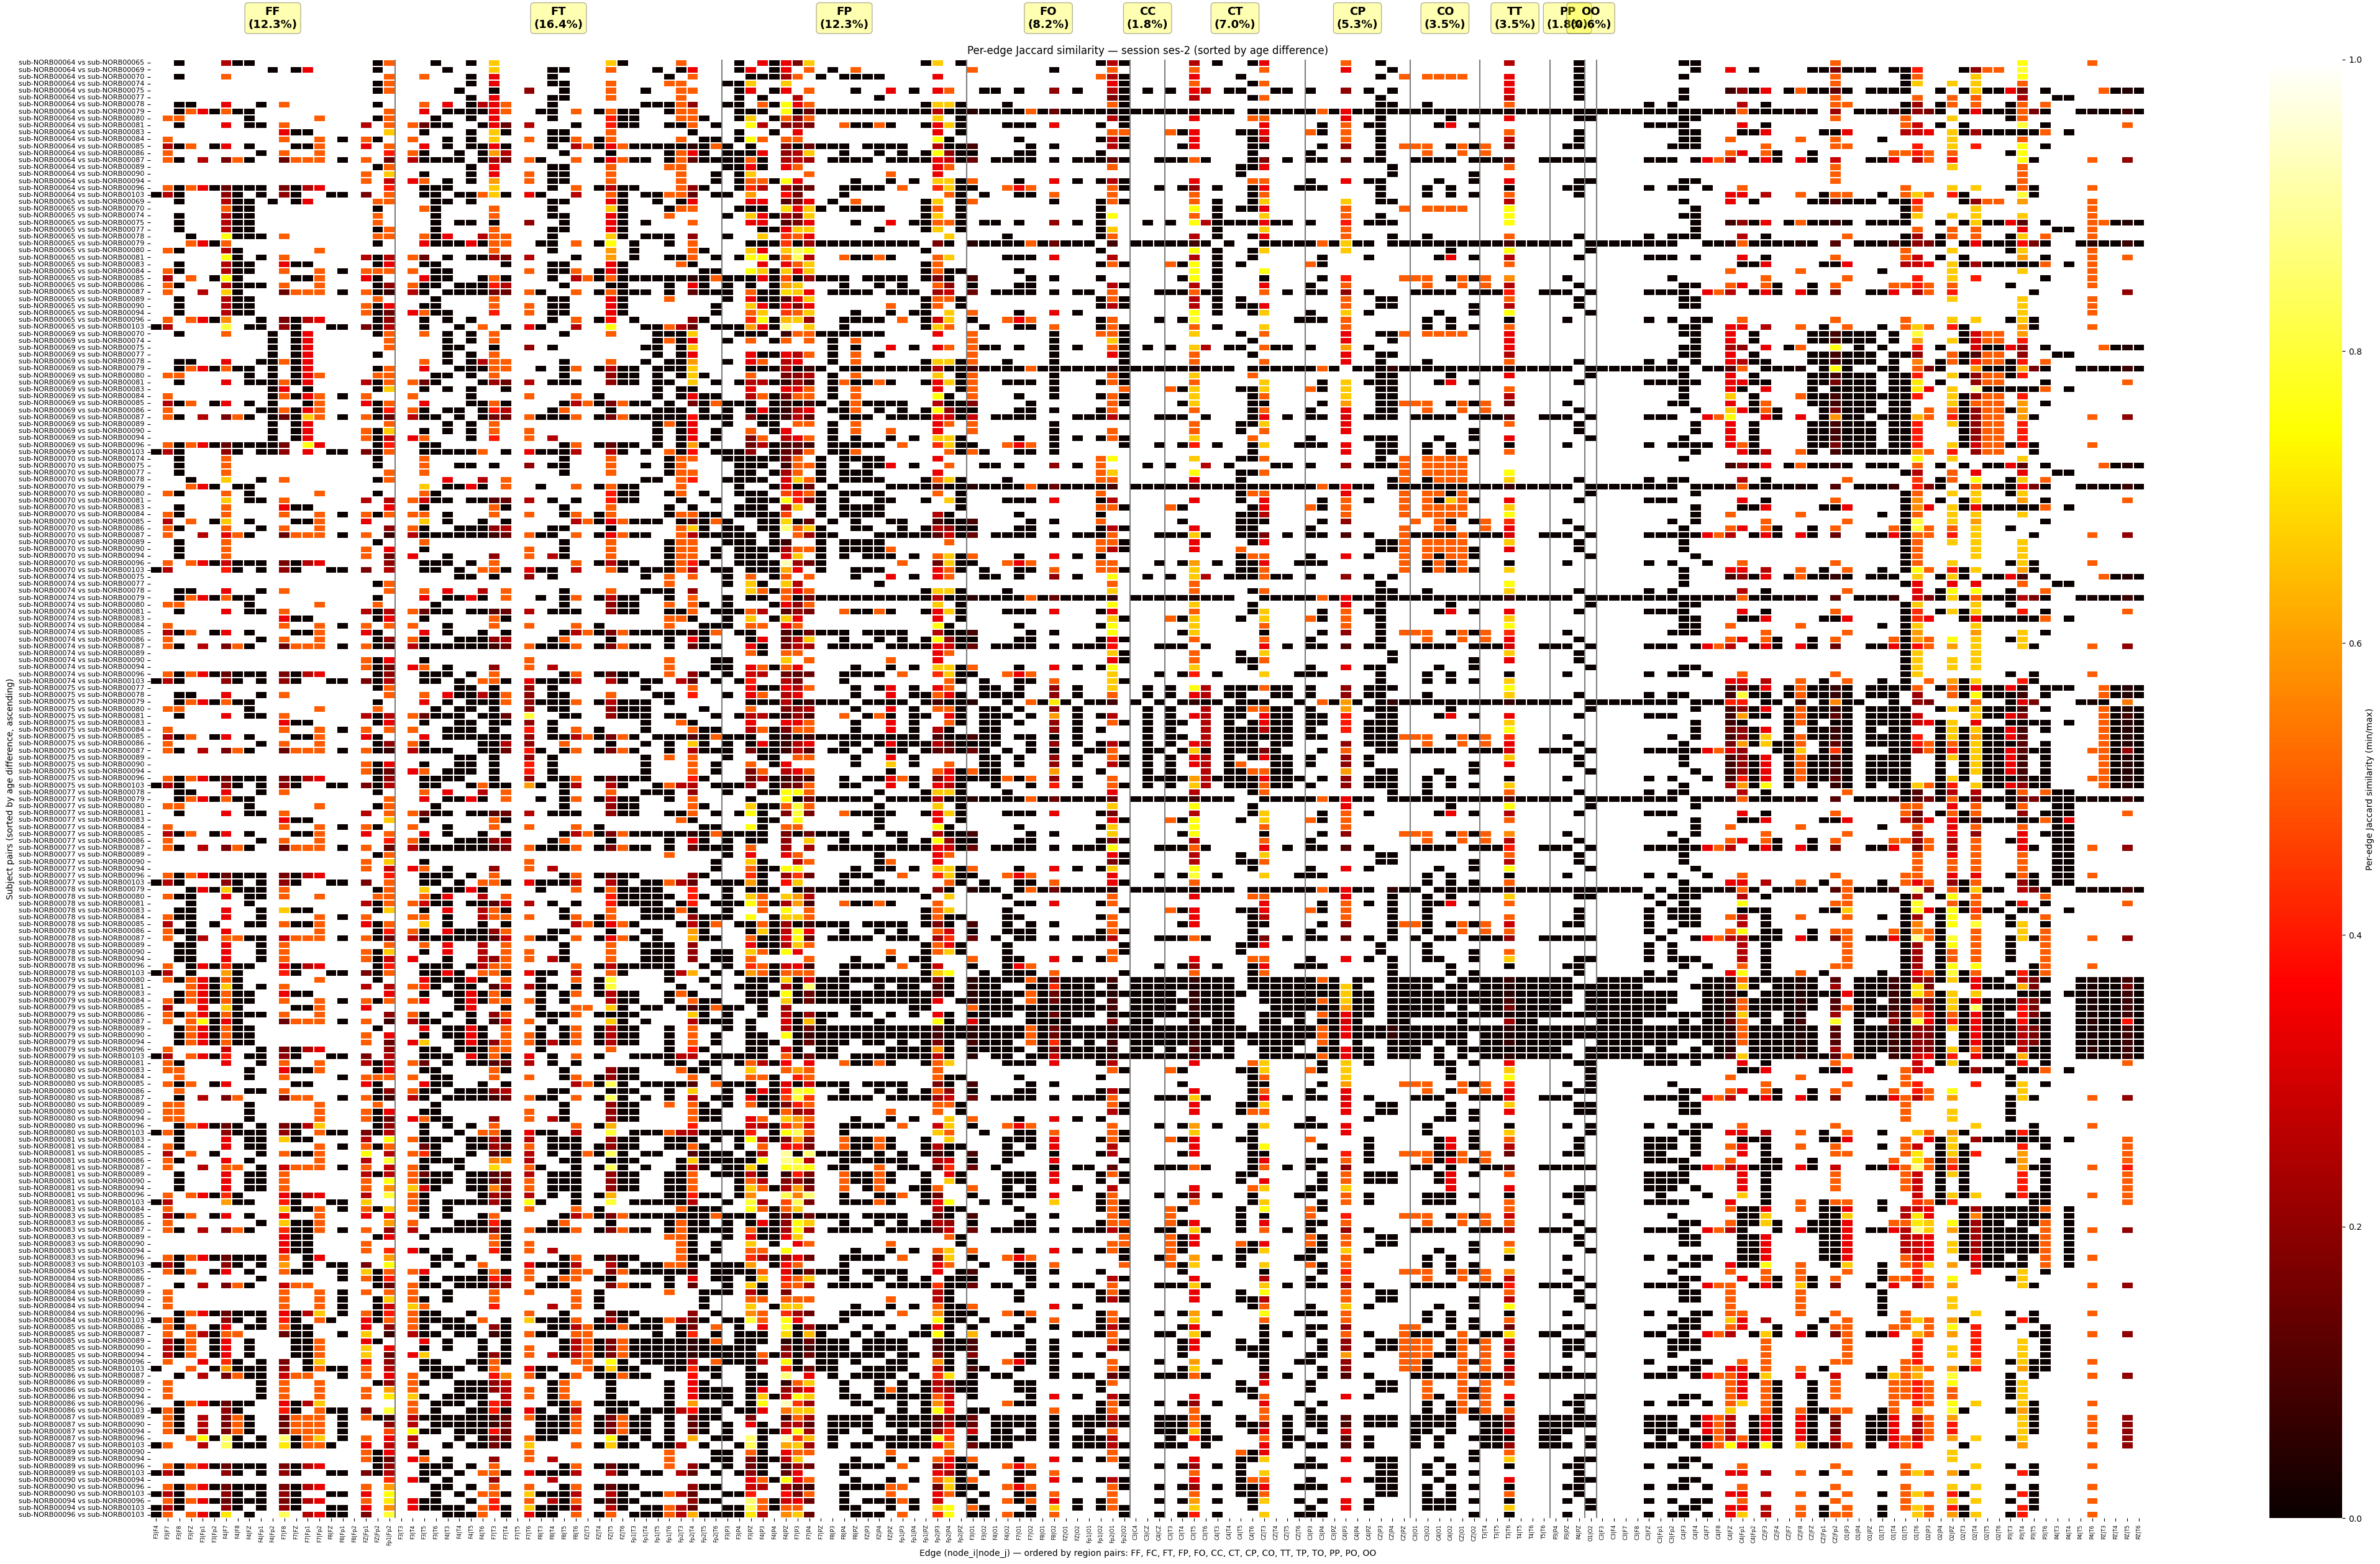

Heatmap plotted: 210 subject pairs × 171 edges.
Sorted by age difference (smallest at bottom, largest at top).
Edge pairs ordered as: FF, FC, FT, FP, FO, CC, CT, CP, CO, TT, TP, TO, PP, PO, OO


In [21]:
# Ensure subject_session_age is defined
if 'subject_session_age' not in globals():
    subject_session_age = {}

# Heatmap for ses-2: per-edge Jaccard similarity between subject pairs (sorted by age difference)
if 'edge_betweenness_df' not in globals() or edge_betweenness_df.empty:
    print("edge_betweenness_df not found or empty. Run the previous cell first.")
else:
    session_sel = 'ses-2'
    sess_df = edge_betweenness_df[edge_betweenness_df['session_id'] == session_sel]

    # Identify subjects with >=2 sessions (use session_node_centrality_df if available)
    if 'session_node_centrality_df' in globals() and not session_node_centrality_df.empty:
        subj_counts = session_node_centrality_df.groupby('subject_id')['session_id'].nunique()
        eligible_subjects = subj_counts[subj_counts >= 2].index.tolist()
    else:
        eligible_subjects = []

    subjects = sorted(sess_df[sess_df['subject_id'].isin(eligible_subjects)]['subject_id'].unique())
    if len(subjects) < 2:
        print(f"No eligible subjects with >=2 sessions for {session_sel} (found {len(subjects)}).")
    else:
        # Sort edges by region pair ordering: FF, FC, FT, FP, FO, CC, CT, CP, CO, TT, TP, TO, PP, PO, OO
        all_edges = list(edge_betweenness_df.sort_values('edge_index')['edge'].drop_duplicates())
        edges = sorted(all_edges, key=get_edge_region_pair_order)

        # build aligned vectors per subject (length = n_edges)
        subj_vectors = {}
        for subj in subjects:
            subdf = sess_df[sess_df['subject_id'] == subj]
            if len(subdf) == len(edges):
                v = subdf.sort_values('edge_index')['edge_betweenness'].to_numpy()
            else:
                # align by edge label, fill missing with 0.0
                tmp = pd.Series(0.0, index=edges)
                s = subdf.set_index('edge')['edge_betweenness'] if not subdf.empty else pd.Series(dtype=float)
                for e, val in s.items():
                    if e in tmp.index:
                        tmp.at[e] = val
                v = tmp.to_numpy()
            subj_vectors[subj] = np.maximum(v, 0.0)

        # Extract age information for subjects (if available)
        subject_ages = {}
        if subject_session_age:
            for subj in subjects:
                key = f"{subj}_{session_sel}"
                if key in subject_session_age:
                    subject_ages[subj] = subject_session_age[key]
        
        # compute per-edge similarity for each subject pair: min/max per edge (define 1.0 when both zero)
        # Initialize pair_data fresh to avoid stale data from previous runs
        pair_data = []
        for i in range(len(subjects)):
            for j in range(i + 1, len(subjects)):
                a = subjects[i]
                b = subjects[j]
                va = subj_vectors[a]
                vb = subj_vectors[b]
                denom = np.maximum(va, vb)
                sim = np.zeros_like(va)
                both_zero = denom == 0
                sim[both_zero] = 1.0
                nz = ~both_zero
                sim[nz] = np.minimum(va[nz], vb[nz]) / denom[nz]
                
                # Calculate age difference if available
                age_diff = None
                if a in subject_ages and b in subject_ages:
                    try:
                        age_a = float(str(subject_ages[a]).timestamp()) if hasattr(subject_ages[a], 'timestamp') else float(subject_ages[a])
                        age_b = float(str(subject_ages[b]).timestamp()) if hasattr(subject_ages[b], 'timestamp') else float(subject_ages[b])
                        age_diff = abs(age_a - age_b)
                    except (ValueError, TypeError, AttributeError):
                        age_diff = float('inf')  # Subjects without age go to end
                else:
                    age_diff = float('inf')
                
                pair_data.append({
                    'subject_a': a,
                    'subject_b': b,
                    'similarity': sim,
                    'age_diff': age_diff,
                    'label': f"{a} vs {b}"
                })
        
        # Sort by age difference (ascending)
        pair_data_sorted = sorted(pair_data, key=lambda x: x['age_diff'])
        
        pair_labels = [p['label'] for p in pair_data_sorted]
        heatmap_rows = [p['similarity'] for p in pair_data_sorted]
        heatmap_matrix = np.array(heatmap_rows)

        # Plot heatmap
        plt.figure(figsize=(max(20, len(edges) * 0.25), max(4, heatmap_matrix.shape[0] * 0.12)))
        ax = sns.heatmap(
            heatmap_matrix,
            xticklabels=edges,
            yticklabels=pair_labels,
            cmap='hot',
            vmin=0.0, vmax=1.0,
            cbar_kws={'label': 'Per-edge Jaccard similarity (min/max)'},
            linewidths=0.2,
        )
        
        # Add region pair cluster labels
        add_region_cluster_labels(ax, edges)
        
        plt.title(f"Per-edge Jaccard similarity — session {session_sel} (sorted by age difference)")
        plt.xlabel('Edge (node_i|node_j) — ordered by region pairs: FF, FC, FT, FP, FO, CC, CT, CP, CO, TT, TP, TO, PP, PO, OO')
        plt.ylabel('Subject pairs (sorted by age difference, ascending)')
        plt.xticks(rotation=90, fontsize=6)
        plt.yticks(fontsize=8)
        plt.tight_layout()

        output_dir = Path("heatmap_outputs")
        output_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_dir / f"per_edge_jaccard_similarity_{session_sel}.png", dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Heatmap plotted: {heatmap_matrix.shape[0]} subject pairs × {heatmap_matrix.shape[1]} edges.")
        print(f"Sorted by age difference (smallest at bottom, largest at top).")
        print(f"Edge pairs ordered as: FF, FC, FT, FP, FO, CC, CT, CP, CO, TT, TP, TO, PP, PO, OO")